# 1. Introduction

This notebook implements SISA (Sharded, Isolated, Sliced and Aggregated) unlearning for the Adult Income machine-unlearning experiments.

SISA partitions the original training set into isolated shards, trains one model per shard through ordered slices, and later handles deletion requests by retraining only affected shards from the earliest affected slice. The resulting shard models are aggregated by averaging predicted probabilities.

The experiment uses the existing Adult Income train/validation/test split, forget sets, retain sets, baseline model, and full-retraining reference models from the previous notebooks. It does not regenerate preprocessing, data splits, forget requests, or full-retraining artefacts.

# 2. Imports and Setup

This section imports the standard scientific Python stack, PyTorch, the existing shared reference-based evaluator, and project utilities. The SISA output directory is separated from previous methods under `results/sisa/adult/`.

## 2.1 Import Libraries

Core scientific Python, plotting, PyTorch and scikit-learn imports are kept together so dependency setup is easy to scan.

In [1]:
from pathlib import Path
import importlib
import json
import random
import sys
import time
from copy import deepcopy

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

## 2.2 Load Shared Evaluation Helpers

The shared reference-based evaluator is reloaded explicitly so this notebook uses the latest local version during interactive work.

In [2]:
PROJECT_CODE_DIR = Path("../..").resolve()
if str(PROJECT_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE_DIR))

import unlearning_evaluation
unlearning_evaluation = importlib.reload(unlearning_evaluation)
from unlearning_evaluation import (
    evaluate_unlearning_method,
    plot_forget_loss_ecdf,
    plot_forget_set_fidelity,
    plot_runtime_vs_forget_set_fidelity,
    plot_utility_delta,
)

## 2.3 Configure Plotting and Experiment Constants

The SISA configuration is fixed before training. These values are reused throughout the notebook.

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42
NUM_SHARDS = 5
NUM_SLICES = 5
SISA_BATCH_SIZE = 256
SISA_LEARNING_RATE = 0.001
SISA_MAX_EPOCHS_PER_SLICE = 4
SISA_EARLY_STOPPING_PATIENCE = 2
SISA_EARLY_STOPPING_MIN_DELTA = 1e-4
CLASSIFICATION_THRESHOLD = 0.5

## 2.4 Set Random Seed and Device

The same seed is applied across Python, NumPy and PyTorch before selecting the available compute device.

In [4]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use Apple Silicon GPU through MPS when available, then CUDA, otherwise CPU.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## 2.5 Define Project Paths

Input artefacts are read from previous notebooks. SISA outputs are isolated under `results/sisa/adult/`.

In [5]:
notebook_dir = Path.cwd()
project_root = Path("../..").resolve()
processed_adult_dir = project_root / "data" / "processed" / "adult"
baseline_models_dir = project_root / "models" / "adult"
baseline_metrics_dir = project_root / "results" / "metrics"
baseline_tables_dir = project_root / "results" / "tables"
full_retraining_dir = project_root / "results" / "full_retraining" / "adult"

sisa_dir = project_root / "results" / "sisa" / "adult"
sisa_configuration_dir = sisa_dir / "configuration"
sisa_partitions_dir = sisa_dir / "partitions"
sisa_original_models_dir = sisa_dir / "original_models"
sisa_unlearned_models_dir = sisa_dir / "unlearned_models"
sisa_histories_dir = sisa_dir / "histories"
sisa_metrics_dir = sisa_dir / "metrics"
sisa_tables_dir = sisa_dir / "tables"
sisa_predictions_dir = sisa_dir / "predictions"
sisa_figures_dir = sisa_dir / "figures"

## 2.6 Create Output Directories

All SISA output folders are created before training, evaluation and export steps write files.

In [6]:
for output_dir in [
    sisa_configuration_dir,
    sisa_partitions_dir,
    sisa_original_models_dir,
    sisa_unlearned_models_dir,
    sisa_histories_dir,
    sisa_metrics_dir,
    sisa_tables_dir,
    sisa_predictions_dir,
    sisa_figures_dir,
]:
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Device: {device}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Number of shards: {NUM_SHARDS}")
print(f"Number of slices per shard: {NUM_SLICES}")
print(f"Main output directory: {sisa_dir}")

Project root: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code
Device: mps
Random seed: 42
Number of shards: 5
Number of slices per shard: 5
Main output directory: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/results/sisa/adult


# 3. Load Previous Outputs

This section loads all data and model artefacts created earlier. No preprocessing, train/test splitting, forget-set construction or full retraining is repeated.

## 3.1 Locate Notebook 1 Artefacts

The baseline data, model, preprocessing and metric paths are collected first so missing files fail early.

In [7]:
baseline_paths = {
    "x_train_processed": processed_adult_dir / "X_train_processed.csv",
    "x_val_processed": processed_adult_dir / "X_val_processed.csv",
    "x_test_processed": processed_adult_dir / "X_test_processed.csv",
    "y_train": processed_adult_dir / "y_train.csv",
    "y_val": processed_adult_dir / "y_val.csv",
    "y_test": processed_adult_dir / "y_test.csv",
    "baseline_model": baseline_models_dir / "adult_income_baseline_mlp.pt",
    "scaler": baseline_models_dir / "adult_income_scaler.joblib",
    "encoder": baseline_models_dir / "adult_income_onehot_encoder.joblib",
    "feature_names": baseline_tables_dir / "adult_processed_feature_names.csv",
    "baseline_metrics": baseline_metrics_dir / "adult_baseline_mlp_metrics.csv",
    "baseline_predictions": baseline_tables_dir / "adult_baseline_mlp_test_predictions.csv",
}

missing_paths = [path for path in baseline_paths.values() if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing Notebook 1 artefacts:" + "; ".join(map(str, missing_paths)))

## 3.2 Load Baseline Data and Model Outputs

The fixed processed splits and baseline checkpoint are loaded without changing the data preparation from Notebook 1.

In [8]:
X_train_processed = pd.read_csv(baseline_paths["x_train_processed"], index_col=0)
X_val_processed = pd.read_csv(baseline_paths["x_val_processed"], index_col=0)
X_test_processed = pd.read_csv(baseline_paths["x_test_processed"], index_col=0)
y_train = pd.read_csv(baseline_paths["y_train"], index_col=0).squeeze("columns")
y_val = pd.read_csv(baseline_paths["y_val"], index_col=0).squeeze("columns")
y_test = pd.read_csv(baseline_paths["y_test"], index_col=0).squeeze("columns")
scaler = joblib.load(baseline_paths["scaler"])
encoder = joblib.load(baseline_paths["encoder"])
feature_names = pd.read_csv(baseline_paths["feature_names"])
baseline_metrics = pd.read_csv(baseline_paths["baseline_metrics"])
baseline_predictions = pd.read_csv(baseline_paths["baseline_predictions"])
baseline_checkpoint = torch.load(baseline_paths["baseline_model"], map_location=device)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/f2/sy3606vx4jjgdl5s52mj7h1h0000gn/T/ipykernel_53737/1557387123.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pick

## 3.3 Load Forget, Retain and Full-Retraining Artefacts

The five GDPR-style scenarios and corresponding full-retraining references are loaded from Notebook 2.

In [9]:
scenario_names = [
    "s1_random_1_percent",
    "s2_random_5_percent",
    "s3_simulated_data_provider_withdrawal",
    "s4_random_10_percent",
    "s5_retention_expiry",
]
scenario_file_prefixes = {
    "s1_random_1_percent": "s1",
    "s2_random_5_percent": "s2",
    "s3_simulated_data_provider_withdrawal": "s3",
    "s4_random_10_percent": "s4",
    "s5_retention_expiry": "s5",
}
forget_sets_dir = full_retraining_dir / "forget_sets"
retain_sets_dir = full_retraining_dir / "retain_sets"
retrained_models_dir = full_retraining_dir / "models"
full_retraining_metrics_dir = full_retraining_dir / "metrics"

forget_indices = {
    scenario: np.load(forget_sets_dir / f"{scenario}_forget_indices.npy")
    for scenario in scenario_names
}
retain_indices = {
    scenario: np.load(retain_sets_dir / f"{scenario}_retain_indices.npy")
    for scenario in scenario_names
}
retrained_checkpoints = {
    scenario: torch.load(
        retrained_models_dir / f"{scenario_file_prefixes[scenario]}_retrained_mlp.pt",
        map_location=device,
    )
    for scenario in scenario_names
}
full_retraining_runtime_summary = pd.read_csv(full_retraining_metrics_dir / "runtime_summary.csv")
full_retraining_metrics = pd.read_csv(full_retraining_metrics_dir / "metrics.csv")
full_retraining_mia_summary = pd.read_csv(full_retraining_metrics_dir / "mia_metrics_summary.csv")

/var/folders/f2/sy3606vx4jjgdl5s52mj7h1h0000gn/T/ipykernel_53737/3811715383.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  scenario: torch.load(


## 3.4 Confirm Loaded Shapes

These prints provide a quick check that the notebook is using the expected processed feature space.

In [10]:
print("Loaded existing Adult Income artefacts.")
print(f"Training shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")
print(f"Feature count from baseline checkpoint: {baseline_checkpoint['input_dim']}")

Loaded existing Adult Income artefacts.
Training shape: (34189, 91)
Validation shape: (7326, 91)
Test shape: (7327, 91)
Feature count from baseline checkpoint: 91


# 4. Verify Loaded Assets

These checks confirm feature ordering, index alignment, scenario reconstruction and checkpoint availability before SISA training begins.

## 4.1 Check Split Alignment

The feature and label indices must match within each split, and the train, validation and test indices must remain disjoint.

In [11]:
# Validate loaded artefacts and index relationships.
training_index = pd.Index(X_train_processed.index)
validation_index = pd.Index(X_val_processed.index)
test_index = pd.Index(X_test_processed.index)

assert X_train_processed.index.equals(y_train.index)
assert X_val_processed.index.equals(y_val.index)
assert X_test_processed.index.equals(y_test.index)
assert X_train_processed.shape[1] == baseline_checkpoint["input_dim"]
assert list(X_train_processed.columns) == baseline_checkpoint["processed_feature_names"]
assert list(X_train_processed.columns) == list(X_val_processed.columns) == list(X_test_processed.columns)
assert set(training_index).isdisjoint(set(validation_index))
assert set(training_index).isdisjoint(set(test_index))

## 4.2 Check Scenario Reconstruction

Each retain/forget pair must be disjoint, reconstruct the original training set, and have a matching full-retraining checkpoint.

In [12]:
validation_rows = []
for scenario in scenario_names:
    forget_set = set(forget_indices[scenario])
    retain_set = set(retain_indices[scenario])
    train_set = set(training_index)
    checkpoint_path = retrained_models_dir / f"{scenario_file_prefixes[scenario]}_retrained_mlp.pt"
    row = {
        "scenario": scenario,
        "forget_subset_of_training": forget_set.issubset(train_set),
        "retain_subset_of_training": retain_set.issubset(train_set),
        "retain_forget_overlap": len(retain_set.intersection(forget_set)),
        "reconstructs_training_set": retain_set.union(forget_set) == train_set,
        "full_retraining_checkpoint_exists": checkpoint_path.exists(),
        "forget_count": len(forget_set),
        "retain_count": len(retain_set),
    }
    validation_rows.append(row)
    assert row["forget_subset_of_training"]
    assert row["retain_subset_of_training"]
    assert row["retain_forget_overlap"] == 0
    assert row["reconstructs_training_set"]
    assert row["full_retraining_checkpoint_exists"]

loaded_asset_checks = pd.DataFrame(validation_rows)
loaded_asset_checks

,scenario,forget_subset_of_training,retain_subset_of_training,retain_forget_overlap,reconstructs_training_set,full_retraining_checkpoint_exists,forget_count,retain_count
0,s1_random_1_percent,True,True,0,True,True,342,33847
1,s2_random_5_percent,True,True,0,True,True,1709,32480
2,s3_simulated_data_provider_withdrawal,True,True,0,True,True,1698,32491
3,s4_random_10_percent,True,True,0,True,True,3419,30770
4,s5_retention_expiry,True,True,0,True,True,5585,28604


# 5. Define Baseline MLP and SISA Helpers

This section reconstructs the same Adult Income MLP architecture used by the previous notebooks and defines SISA-specific training, checkpointing, prediction and aggregation helpers.

## 5.1 Define Model Architecture and Loss

The MLP architecture and binary cross-entropy loss match the previous Adult Income notebooks.

In [13]:
class AdultIncomeMLP(nn.Module):
    """Small MLP for binary Adult Income classification."""

    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1),
        )

    def forward(self, features):
        return self.network(features)

input_dim = X_train_processed.shape[1]
criterion = nn.BCEWithLogitsLoss()

## 5.2 Define Seeding and DataLoader Helpers

These helpers initialise shard models deterministically and build training/evaluation loaders from existing processed records.

In [14]:
def set_torch_seed(seed: int) -> None:
    """Set deterministic seeds for model initialisation and loaders."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def initialise_shard_model(shard_id: int) -> AdultIncomeMLP:
    """Initialise one shard MLP deterministically."""
    set_torch_seed(RANDOM_SEED + int(shard_id))
    return AdultIncomeMLP(input_dim=input_dim).to(device)


def create_index_data_loader(indices, batch_size=SISA_BATCH_SIZE, shuffle=True, seed=RANDOM_SEED):
    """Construct a DataLoader from training record indices."""
    index_array = np.array(indices)
    features = torch.tensor(X_train_processed.loc[index_array].to_numpy(dtype=np.float32), dtype=torch.float32)
    labels = torch.tensor(y_train.loc[index_array].to_numpy(dtype=np.float32).reshape(-1, 1), dtype=torch.float32)
    dataset = TensorDataset(features, labels)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


def create_feature_data_loader(features, labels, batch_size=SISA_BATCH_SIZE):
    """Construct a DataLoader from arbitrary features and labels."""
    feature_tensor = torch.tensor(features.to_numpy(dtype=np.float32), dtype=torch.float32)
    label_tensor = torch.tensor(labels.to_numpy(dtype=np.float32).reshape(-1, 1), dtype=torch.float32)
    return DataLoader(TensorDataset(feature_tensor, label_tensor), batch_size=batch_size, shuffle=False)

## 5.3 Define Validation-Loss Helper

Validation loss is used for slice-level early stopping and is evaluated on the fixed validation split.

In [15]:
def evaluate_average_loss(model, features=X_val_processed, labels=y_val):
    """Evaluate binary cross-entropy loss on a fixed feature set."""
    data_loader = create_feature_data_loader(features, labels, batch_size=SISA_BATCH_SIZE)
    model.eval()
    running_loss = 0.0
    record_count = 0
    with torch.no_grad():
        for batch_features, batch_labels in data_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            logits = model(batch_features)
            loss = criterion(logits, batch_labels)
            running_loss += loss.item() * batch_features.size(0)
            record_count += batch_features.size(0)
    return running_loss / record_count

## 5.4 Define Slice Training Helper

Each shard is trained slice by slice, with best-checkpoint restoration inside each slice training call.

In [16]:
def train_one_slice(model, train_indices, shard_id, slice_id, max_epochs=SISA_MAX_EPOCHS_PER_SLICE):
    """Train one sequential SISA slice and return training metadata."""
    if len(train_indices) == 0:
        return {
            "epochs_completed": 0,
            "optimizer_steps": 0,
            "final_training_loss": np.nan,
            "final_validation_loss": evaluate_average_loss(model),
            "history": [],
        }

    optimizer = torch.optim.Adam(model.parameters(), lr=SISA_LEARNING_RATE)
    train_loader = create_index_data_loader(
        train_indices,
        batch_size=SISA_BATCH_SIZE,
        shuffle=True,
        seed=RANDOM_SEED + shard_id * 100 + slice_id,
    )
    best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
    best_val_loss = np.inf
    epochs_without_improvement = 0
    optimizer_steps = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad()
            logits = model(batch_features)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            optimizer_steps += 1
            running_loss += loss.item() * batch_features.size(0)
            seen += batch_features.size(0)

        train_loss = running_loss / seen
        val_loss = evaluate_average_loss(model)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss - SISA_EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= SISA_EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict({key: value.to(device) for key, value in best_state.items()})
    return {
        "epochs_completed": len(history),
        "optimizer_steps": optimizer_steps,
        "final_training_loss": history[-1]["train_loss"],
        "final_validation_loss": best_val_loss,
        "history": history,
    }

## 5.5 Define Checkpoint Helpers

SISA checkpoints store the model state and enough metadata to reconstruct the shard model later.

In [17]:
def save_sisa_checkpoint(model, path, metadata):
    """Save a SISA model checkpoint with metadata."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"model_state_dict": model.state_dict(), "input_dim": input_dim, **metadata}, path)


def load_sisa_checkpoint(path):
    """Load a SISA model checkpoint."""
    checkpoint = torch.load(path, map_location=device)
    model = AdultIncomeMLP(input_dim=checkpoint["input_dim"]).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def load_model_from_checkpoint(checkpoint):
    """Load an AdultIncomeMLP from an existing project checkpoint."""
    model = AdultIncomeMLP(input_dim=checkpoint["input_dim"]).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

## 5.6 Define Prediction and Aggregation Helpers

SISA prediction averages one valid probability vector from each shard model.

In [18]:
def predict_with_model(model, features, batch_size=SISA_BATCH_SIZE):
    """Predict probabilities and binary labels for one model."""
    feature_tensor = torch.tensor(features.to_numpy(dtype=np.float32), dtype=torch.float32)
    loader = DataLoader(TensorDataset(feature_tensor), batch_size=batch_size, shuffle=False)
    probabilities = []
    model.eval()
    with torch.no_grad():
        for (batch_features,) in loader:
            batch_features = batch_features.to(device)
            logits = model(batch_features)
            batch_probabilities = torch.sigmoid(logits).cpu().numpy().ravel()
            probabilities.extend(batch_probabilities)
    probabilities = np.array(probabilities)
    predictions = (probabilities >= CLASSIFICATION_THRESHOLD).astype(int)
    return probabilities, predictions


def validate_probability_vector(probabilities, expected_length, context):
    """Validate one probability per input record."""
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = np.squeeze(probabilities) if probabilities.ndim > 1 else probabilities
    if probabilities.ndim != 1:
        raise RuntimeError(f"{context}: probabilities must be one-dimensional after squeezing.")
    if len(probabilities) != expected_length:
        raise RuntimeError(f"{context}: expected {expected_length} probabilities, got {len(probabilities)}.")
    if not np.isfinite(probabilities).all():
        raise RuntimeError(f"{context}: probabilities contain non-finite values.")
    if ((probabilities < 0) | (probabilities > 1)).any():
        raise RuntimeError(f"{context}: probabilities must be between zero and one.")
    return probabilities


def aggregate_shard_predictions(shard_models, features, batch_size=SISA_BATCH_SIZE):
    """Average predicted probabilities across all shard models."""
    shard_probability_rows = []
    for shard_id in sorted(shard_models):
        probabilities, _ = predict_with_model(shard_models[shard_id], features, batch_size=batch_size)
        probabilities = validate_probability_vector(probabilities, len(features), f"shard {shard_id}")
        shard_probability_rows.append(probabilities)
    if len(shard_probability_rows) != NUM_SHARDS:
        raise RuntimeError(f"Expected {NUM_SHARDS} shard outputs, got {len(shard_probability_rows)}.")
    aggregated = np.mean(np.vstack(shard_probability_rows), axis=0)
    return validate_probability_vector(aggregated, len(features), "aggregated SISA predictor")

## 5.7 Reconstruct Baseline and Full-Retraining Models

These reference models are used later by the shared evaluation framework.

In [19]:
baseline_model = load_model_from_checkpoint(baseline_checkpoint)
retrained_models = {scenario: load_model_from_checkpoint(retrained_checkpoints[scenario]) for scenario in scenario_names}
print("Defined SISA model and helper functions.")

Defined SISA model and helper functions.


# 6. SISA Unlearning

This section configures the fixed SISA partition, trains the original SISA system, maps deletion requests, and retrains only affected shards for each scenario.

## 6.1 Configure SISA Parameters

The SISA configuration is fixed before model training and is not tuned against the test set.

In [20]:
sisa_configuration = {
    "method": "sisa",
    "number_of_shards": NUM_SHARDS,
    "number_of_slices_per_shard": NUM_SLICES,
    "aggregation": "mean_predicted_probability",
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "random_seed": RANDOM_SEED,
    "model_architecture": "AdultIncomeMLP_108_64_32_1_dropout_0.2",
    "loss": "BCEWithLogitsLoss",
    "optimizer": "Adam",
    "batch_size": SISA_BATCH_SIZE,
    "learning_rate": SISA_LEARNING_RATE,
    "maximum_epochs_per_slice": SISA_MAX_EPOCHS_PER_SLICE,
    "early_stopping_patience": SISA_EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": SISA_EARLY_STOPPING_MIN_DELTA,
    "partition_strategy": "deterministic_stratified_shards_then_stratified_slices",
}

sisa_configuration_path = sisa_configuration_dir / "sisa_configuration.json"
with open(sisa_configuration_path, "w") as file:
    json.dump(sisa_configuration, file, indent=2)

sisa_configuration_table = pd.DataFrame(
    [{"setting": key, "value": value} for key, value in sisa_configuration.items()]
)
print(f"Saved SISA configuration to: {sisa_configuration_path}")
sisa_configuration_table

Saved SISA configuration to: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/results/sisa/adult/configuration/sisa_configuration.json


,setting,value
0,method,sisa
1,number_of_shards,5
2,number_of_slices_per_shard,5
3,aggregation,mean_predicted_probability
4,classification_threshold,0.5
5,random_seed,42
6,model_architecture,AdultIncomeMLP_108_64_32_1_dropout_0.2
7,loss,BCEWithLogitsLoss
8,optimizer,Adam
9,batch_size,256


## 6.2 Create a Fixed Shard Partition

Every training record is assigned to exactly one shard using deterministic stratified folds. A shard model only trains on records assigned to that shard.

### 6.2.1 Define Shard Assignment Function

The assignment function keeps class balance approximately stable across isolated shards.

In [21]:
def create_stratified_shard_assignments(index, labels, num_shards, seed):
    """Assign each training record to exactly one stratified shard."""
    assignments = []
    splitter = StratifiedKFold(n_splits=num_shards, shuffle=True, random_state=seed)
    dummy_features = np.zeros(len(index))
    labels_array = labels.loc[index].to_numpy()

    for shard_id, (_, shard_positions) in enumerate(splitter.split(dummy_features, labels_array), start=1):
        shard_indices = index[shard_positions]
        for original_index in shard_indices:
            assignments.append(
                {
                    "original_index": original_index,
                    "shard_id": shard_id,
                    "class_label": int(labels.loc[original_index]),
                }
            )

    return pd.DataFrame(assignments).sort_values("original_index").reset_index(drop=True)

### 6.2.2 Build and Validate Shard Assignments

The saved shard table is checked for uniqueness, full training-set coverage and no leakage into validation or test records.

In [22]:
shard_assignments = create_stratified_shard_assignments(
    index=training_index.to_numpy(),
    labels=y_train,
    num_shards=NUM_SHARDS,
    seed=RANDOM_SEED,
)
shard_assignments_path = sisa_partitions_dir / "shard_assignments.csv"
shard_assignments.to_csv(shard_assignments_path, index=False)

shard_summary = (
    shard_assignments
    .groupby("shard_id")
    .agg(
        record_count=("original_index", "count"),
        class_0_count=("class_label", lambda values: int((values == 0).sum())),
        class_1_count=("class_label", lambda values: int((values == 1).sum())),
    )
    .reset_index()
)
shard_summary["class_0_proportion"] = shard_summary["class_0_count"] / shard_summary["record_count"]
shard_summary["class_1_proportion"] = shard_summary["class_1_count"] / shard_summary["record_count"]

assert shard_assignments["original_index"].is_unique
assert set(shard_assignments["original_index"]) == set(training_index)
assert set(shard_assignments["original_index"]).isdisjoint(set(validation_index))
assert set(shard_assignments["original_index"]).isdisjoint(set(test_index))

print(f"Saved shard assignments to: {shard_assignments_path}")
shard_summary

Saved shard assignments to: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/results/sisa/adult/partitions/shard_assignments.csv


,shard_id,record_count,class_0_count,class_1_count,class_0_proportion,class_1_proportion
0,1,6838,5202,1636,0.760749,0.239251
1,2,6838,5202,1636,0.760749,0.239251
2,3,6838,5202,1636,0.760749,0.239251
3,4,6838,5201,1637,0.760603,0.239397
4,5,6837,5201,1636,0.760714,0.239286


## 6.3 Create Ordered Slices

Each shard is split into five deterministic, ordered slices. Slice checkpoints are cumulative: a later checkpoint contains the influence of earlier slices because training continues sequentially from the previous slice checkpoint.

### 6.3.1 Define Slice Assignment Function

Within each shard, records are ordered deterministically and split into fixed slices.

In [23]:
def create_slice_assignments(shard_assignments, num_slices, seed):
    """Create deterministic ordered slices within every shard."""
    rng = np.random.default_rng(seed)
    rows = []

    for shard_id, shard_frame in shard_assignments.groupby("shard_id"):
        shard_indices = shard_frame["original_index"].to_numpy()
        shard_labels = shard_frame.set_index("original_index")["class_label"]
        ordered_indices = []
        for class_label in sorted(shard_frame["class_label"].unique()):
            class_indices = shard_frame.loc[
                shard_frame["class_label"] == class_label,
                "original_index",
            ].to_numpy()
            class_indices = rng.permutation(class_indices)
            ordered_indices.extend(class_indices.tolist())
        ordered_indices = np.array(ordered_indices)
        ordered_indices = rng.permutation(ordered_indices)
        split_indices = np.array_split(ordered_indices, num_slices)

        within_order = 0
        for slice_id, slice_indices in enumerate(split_indices, start=1):
            for original_index in slice_indices:
                rows.append(
                    {
                        "original_index": original_index,
                        "shard_id": int(shard_id),
                        "slice_id": int(slice_id),
                        "within_shard_order": within_order,
                        "class_label": int(shard_labels.loc[original_index]),
                    }
                )
                within_order += 1

    return pd.DataFrame(rows).sort_values(["shard_id", "within_shard_order"]).reset_index(drop=True)

### 6.3.2 Build and Validate Slice Assignments

Every training record must appear in exactly one shard-slice pair.

In [24]:
slice_assignments = create_slice_assignments(shard_assignments, NUM_SLICES, RANDOM_SEED)
slice_assignments_path = sisa_partitions_dir / "slice_assignments.csv"
slice_assignments.to_csv(slice_assignments_path, index=False)

slice_summary = (
    slice_assignments
    .groupby(["shard_id", "slice_id"])
    .agg(
        slice_record_count=("original_index", "count"),
        class_0_count=("class_label", lambda values: int((values == 0).sum())),
        class_1_count=("class_label", lambda values: int((values == 1).sum())),
    )
    .reset_index()
)
slice_summary["cumulative_record_count"] = slice_summary.groupby("shard_id")["slice_record_count"].cumsum()
slice_summary["class_1_proportion"] = slice_summary["class_1_count"] / slice_summary["slice_record_count"]

for shard_id in range(1, NUM_SHARDS + 1):
    shard_records = set(shard_assignments.loc[shard_assignments["shard_id"] == shard_id, "original_index"])
    shard_slices = slice_assignments.loc[slice_assignments["shard_id"] == shard_id]
    assert shard_slices["original_index"].is_unique
    assert set(shard_slices["original_index"]) == shard_records

assert slice_assignments["original_index"].is_unique
assert set(slice_assignments["original_index"]) == set(training_index)
print(f"Saved slice assignments to: {slice_assignments_path}")
slice_summary.head(10)

Saved slice assignments to: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/results/sisa/adult/partitions/slice_assignments.csv


,shard_id,slice_id,slice_record_count,class_0_count,class_1_count,cumulative_record_count,class_1_proportion
0,1,1,1368,1039,329,1368,0.240497
1,1,2,1368,1025,343,2736,0.250731
2,1,3,1368,1039,329,4104,0.240497
3,1,4,1367,1053,314,5471,0.229700
4,1,5,1367,1046,321,6838,0.234821
5,2,1,1368,1035,333,1368,0.243421
6,2,2,1368,1019,349,2736,0.255117
7,2,3,1368,1053,315,4104,0.230263
8,2,4,1367,1038,329,5471,0.240673
9,2,5,1367,1057,310,6838,0.226774


## 6.4 Train the Original SISA System

One isolated model is trained per shard. Within each shard, slice training is sequential and checkpoints are saved after every slice. The original setup cost is recorded separately from deletion-request runtime.

### 6.4.1 Initialise Original SISA Training Logs

These containers collect per-slice summaries, training histories and shard-level setup runtime.

In [25]:
original_sisa_models = {}
original_training_rows = []
original_training_history_rows = []
original_shard_runtime_rows = []
original_setup_start = time.perf_counter()

### 6.4.2 Train and Checkpoint Shards

Each shard starts from a deterministic initial state and is trained sequentially through its slices.

In [26]:
for shard_id in range(1, NUM_SHARDS + 1):
    shard_start = time.perf_counter()
    model = initialise_shard_model(shard_id)
    cumulative_indices = []
    previous_checkpoint = "deterministic_initial_state"

    for slice_id in range(1, NUM_SLICES + 1):
        slice_indices = slice_assignments.loc[
            (slice_assignments["shard_id"] == shard_id)
            & (slice_assignments["slice_id"] == slice_id),
            "original_index",
        ].to_numpy()
        cumulative_indices.extend(slice_indices.tolist())
        slice_start = time.perf_counter()
        train_result = train_one_slice(model, slice_indices, shard_id, slice_id)
        runtime_seconds = time.perf_counter() - slice_start
        checkpoint_path = sisa_original_models_dir / f"shard_{shard_id}" / f"slice_{slice_id}.pt"
        save_sisa_checkpoint(
            model,
            checkpoint_path,
            {
                "shard_id": shard_id,
                "slice_id": slice_id,
                "seed": RANDOM_SEED + shard_id,
                "slice_record_count": len(slice_indices),
                "cumulative_record_count": len(cumulative_indices),
                "learning_rate": SISA_LEARNING_RATE,
                "batch_size": SISA_BATCH_SIZE,
                "max_epochs_per_slice": SISA_MAX_EPOCHS_PER_SLICE,
            },
        )
        original_training_rows.append(
            {
                "shard_id": shard_id,
                "slice_id": slice_id,
                "slice_record_count": len(slice_indices),
                "cumulative_record_count": len(cumulative_indices),
                "epochs_completed": train_result["epochs_completed"],
                "optimizer_steps": train_result["optimizer_steps"],
                "final_training_loss": train_result["final_training_loss"],
                "final_validation_loss": train_result["final_validation_loss"],
                "runtime_seconds": runtime_seconds,
                "starting_checkpoint": previous_checkpoint,
                "saved_checkpoint": str(checkpoint_path),
                "seed": RANDOM_SEED + shard_id,
            }
        )
        for history_row in train_result["history"]:
            original_training_history_rows.append({"shard_id": shard_id, "slice_id": slice_id, **history_row})
        previous_checkpoint = str(checkpoint_path)

    final_model_path = sisa_original_models_dir / f"shard_{shard_id}" / "final_model.pt"
    save_sisa_checkpoint(
        model,
        final_model_path,
        {"shard_id": shard_id, "slice_id": "final", "seed": RANDOM_SEED + shard_id},
    )
    original_sisa_models[shard_id] = deepcopy(model).eval()
    original_shard_runtime_rows.append(
        {
            "shard_id": shard_id,
            "runtime_seconds": time.perf_counter() - shard_start,
            "final_model_path": str(final_model_path),
        }
    )

### 6.4.3 Save Original SISA Training Summaries

The original setup summaries are saved separately from later deletion-request work.

In [27]:
original_sisa_setup_runtime_seconds = time.perf_counter() - original_setup_start
original_sisa_training_summary = pd.DataFrame(original_training_rows)
original_sisa_training_histories = pd.DataFrame(original_training_history_rows)
original_sisa_shard_runtime_summary = pd.DataFrame(original_shard_runtime_rows)
original_sisa_total_optimizer_steps = int(original_sisa_training_summary["optimizer_steps"].sum())

original_sisa_training_summary.to_csv(sisa_tables_dir / "original_sisa_training_summary.csv", index=False)
original_sisa_training_histories.to_csv(sisa_histories_dir / "original_sisa_training_histories.csv", index=False)
original_sisa_shard_runtime_summary.to_csv(sisa_tables_dir / "original_sisa_shard_runtime_summary.csv", index=False)

print(f"Original SISA setup runtime: {original_sisa_setup_runtime_seconds:.2f} seconds")
print(f"Original SISA optimizer steps: {original_sisa_total_optimizer_steps}")
original_sisa_training_summary.head(10)

Original SISA setup runtime: 11.10 seconds
Original SISA optimizer steps: 600


,shard_id,slice_id,slice_record_count,cumulative_record_count,epochs_completed,optimizer_steps,final_training_loss,final_validation_loss,runtime_seconds,starting_checkpoint,saved_checkpoint,seed
0,1,1,1368,1368,4,24,0.591801,0.570265,2.099520,deterministic_initial_state,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
1,1,2,1368,2736,4,24,0.457623,0.423464,0.381238,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
2,1,3,1368,4104,4,24,0.354769,0.338923,0.352694,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
3,1,4,1367,5471,4,24,0.342943,0.322796,0.450573,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
4,1,5,1367,6838,4,24,0.324253,0.316377,0.336918,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
5,2,1,1368,1368,4,24,0.645135,0.616373,0.386229,deterministic_initial_state,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
6,2,2,1368,2736,4,24,0.472152,0.437004,0.382959,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
7,2,3,1368,4104,4,24,0.361193,0.349694,0.348710,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
8,2,4,1367,5471,4,24,0.346608,0.328039,0.359269,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
9,2,5,1367,6838,4,24,0.307144,0.323684,0.364537,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44


## 6.5 Map Deletion Requests to Shards and Slices

Each S1-S5 forget request is mapped onto the fixed SISA partition. This identifies affected shards, affected slices, and the earliest slice from which retraining must restart.

### 6.5.1 Map Forget Records to Partition Locations

Every forget record is mapped to its shard, slice and within-shard order.

In [28]:
slice_lookup = slice_assignments.set_index("original_index")
forget_mapping_rows = []
scenario_summary_rows = []
forget_per_shard_rows = []
forget_per_slice_rows = []
earliest_slice_rows = []

for scenario in scenario_names:
    scenario_forget_indices = forget_indices[scenario]
    for original_index in scenario_forget_indices:
        row = slice_lookup.loc[original_index]
        forget_mapping_rows.append(
            {
                "scenario": scenario,
                "original_index": original_index,
                "shard_id": int(row["shard_id"]),
                "slice_id": int(row["slice_id"]),
                "within_shard_order": int(row["within_shard_order"]),
            }
        )

forget_records_by_shard_and_slice = pd.DataFrame(forget_mapping_rows)
forget_records_by_shard_and_slice.to_csv(sisa_tables_dir / "forget_records_by_shard_and_slice.csv", index=False)

### 6.5.2 Summarise Affected Shards and Slices

The summary identifies which shards and slices must be replayed for each deletion request.

In [29]:
for scenario, frame in forget_records_by_shard_and_slice.groupby("scenario"):
    affected_shards = sorted(frame["shard_id"].unique())
    affected_slices = frame[["shard_id", "slice_id"]].drop_duplicates()
    per_shard = frame.groupby("shard_id").size().to_dict()
    per_slice = frame.groupby(["shard_id", "slice_id"]).size().to_dict()
    earliest = frame.groupby("shard_id")["slice_id"].min().to_dict()
    for shard_id, count in per_shard.items():
        forget_per_shard_rows.append({"scenario": scenario, "shard_id": shard_id, "forget_count": count})
    for (shard_id, slice_id), count in per_slice.items():
        forget_per_slice_rows.append({"scenario": scenario, "shard_id": shard_id, "slice_id": slice_id, "forget_count": count})
    for shard_id, slice_id in earliest.items():
        earliest_slice_rows.append({"scenario": scenario, "shard_id": shard_id, "earliest_affected_slice": slice_id})
    scenario_summary_rows.append(
        {
            "scenario": scenario,
            "forget_size": len(forget_indices[scenario]),
            "forget_percentage": len(forget_indices[scenario]) / len(training_index),
            "affected_shard_count": len(affected_shards),
            "unaffected_shard_count": NUM_SHARDS - len(affected_shards),
            "affected_slice_count": len(affected_slices),
            "forget_records_per_shard": json.dumps({int(k): int(v) for k, v in per_shard.items()}),
            "forget_records_per_slice": json.dumps({f"{int(k[0])}:{int(k[1])}": int(v) for k, v in per_slice.items()}),
            "earliest_affected_slice_per_shard": json.dumps({int(k): int(v) for k, v in earliest.items()}),
        }
    )

forget_request_mapping_summary = pd.DataFrame(scenario_summary_rows)
forget_records_per_shard = pd.DataFrame(forget_per_shard_rows)
forget_records_per_slice = pd.DataFrame(forget_per_slice_rows)
earliest_affected_slice_table = pd.DataFrame(earliest_slice_rows)
forget_request_mapping_summary.to_csv(sisa_tables_dir / "forget_request_mapping_summary.csv", index=False)
forget_request_mapping_summary

,scenario,forget_size,forget_percentage,affected_shard_count,unaffected_shard_count,affected_slice_count,forget_records_per_shard,forget_records_per_slice,earliest_affected_slice_per_shard
0,s1_random_1_percent,342,0.010003,5,0,25,"{""1"": 84, ""2"": 60, ""3"": 62, ""4"": 61, ""5"": 75}","{""1:1"": 24, ""1:2"": 7, ""1:3"": 16, ""1:4"": 20, ""1...","{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}"
1,s2_random_5_percent,1709,0.049987,5,0,25,"{""1"": 361, ""2"": 350, ""3"": 332, ""4"": 346, ""5"": ...","{""1:1"": 72, ""1:2"": 72, ""1:3"": 69, ""1:4"": 80, ""...","{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}"
2,s3_simulated_data_provider_withdrawal,1698,0.049665,5,0,25,"{""1"": 357, ""2"": 345, ""3"": 340, ""4"": 330, ""5"": ...","{""1:1"": 68, ""1:2"": 74, ""1:3"": 67, ""1:4"": 69, ""...","{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}"
3,s4_random_10_percent,3419,0.100003,5,0,25,"{""1"": 652, ""2"": 643, ""3"": 691, ""4"": 723, ""5"": ...","{""1:1"": 120, ""1:2"": 127, ""1:3"": 136, ""1:4"": 13...","{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}"
4,s5_retention_expiry,5585,0.163357,5,0,25,"{""1"": 1145, ""2"": 1118, ""3"": 1096, ""4"": 1124, ""...","{""1:1"": 221, ""1:2"": 245, ""1:3"": 214, ""1:4"": 22...","{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}"


## 6.6 Apply SISA Deletion Procedure

Each scenario is processed independently from the same original SISA system. Affected shards are retrained from the checkpoint immediately before the earliest affected slice, while unaffected shards reuse their original final model.

### 6.6.1 Define Affected-Shard Retraining Helpers

These helpers locate the restart checkpoint and retrain one affected shard after removing the scenario forget records.

In [30]:
def checkpoint_before_slice(shard_id: int, earliest_slice: int):
    """Return the checkpoint path immediately before an affected slice."""
    if earliest_slice == 1:
        return "deterministic_initial_state"
    return sisa_original_models_dir / f"shard_{shard_id}" / f"slice_{earliest_slice - 1}.pt"


def retrain_affected_shard_for_scenario(scenario, shard_id, scenario_forget_set, earliest_slice):
    """Retrain one affected shard from the earliest affected slice onward."""
    starting_checkpoint = checkpoint_before_slice(shard_id, earliest_slice)
    if starting_checkpoint == "deterministic_initial_state":
        model = initialise_shard_model(shard_id)
    else:
        model, _ = load_sisa_checkpoint(starting_checkpoint)

    histories = []
    work_rows = []
    total_steps = 0
    total_runtime = 0.0
    retained_records_reprocessed = 0
    slices_retrained = []

    for slice_id in range(earliest_slice, NUM_SLICES + 1):
        original_slice_indices = slice_assignments.loc[
            (slice_assignments["shard_id"] == shard_id)
            & (slice_assignments["slice_id"] == slice_id),
            "original_index",
        ].to_numpy()
        retained_slice_indices = np.array([idx for idx in original_slice_indices if idx not in scenario_forget_set])
        assert set(retained_slice_indices).isdisjoint(scenario_forget_set)
        retained_records_reprocessed += len(retained_slice_indices)
        slices_retrained.append(slice_id)
        start = time.perf_counter()
        train_result = train_one_slice(model, retained_slice_indices, shard_id, slice_id)
        runtime = time.perf_counter() - start
        total_steps += train_result["optimizer_steps"]
        total_runtime += runtime
        for history_row in train_result["history"]:
            histories.append({"scenario": scenario, "shard_id": shard_id, "slice_id": slice_id, **history_row})

    final_path = sisa_unlearned_models_dir / scenario / f"shard_{shard_id}_final.pt"
    save_sisa_checkpoint(
        model,
        final_path,
        {
            "scenario": scenario,
            "shard_id": shard_id,
            "earliest_affected_slice": earliest_slice,
            "seed": RANDOM_SEED + shard_id,
            "forget_records_removed": int(
                forget_records_by_shard_and_slice.loc[
                    (forget_records_by_shard_and_slice["scenario"] == scenario)
                    & (forget_records_by_shard_and_slice["shard_id"] == shard_id)
                ].shape[0]
            ),
        },
    )
    return model.eval(), {
        "histories": histories,
        "work": {
            "scenario": scenario,
            "shard_id": shard_id,
            "shard_status": "affected",
            "forget_records_in_shard": int(
                forget_records_by_shard_and_slice.loc[
                    (forget_records_by_shard_and_slice["scenario"] == scenario)
                    & (forget_records_by_shard_and_slice["shard_id"] == shard_id)
                ].shape[0]
            ),
            "earliest_affected_slice": earliest_slice,
            "starting_checkpoint": str(starting_checkpoint),
            "slices_retrained": json.dumps(slices_retrained),
            "retained_records_reprocessed": retained_records_reprocessed,
            "deletion_optimizer_steps": total_steps,
            "deletion_runtime_seconds": total_runtime,
            "final_checkpoint": str(final_path),
            "original_checkpoint_reused": False,
        },
    }

### 6.6.2 Process All Scenario Deletion Requests

For each scenario, affected shards are replayed and unaffected shards reuse their original final checkpoint.

In [31]:
scenario_sisa_models = {}
deletion_work_rows = []
deletion_history_rows = []

for scenario in scenario_names:
    scenario_forget_set = set(forget_indices[scenario])
    scenario_sisa_models[scenario] = {}
    scenario_frame = forget_records_by_shard_and_slice.loc[forget_records_by_shard_and_slice["scenario"] == scenario]
    earliest_by_shard = scenario_frame.groupby("shard_id")["slice_id"].min().to_dict()

    for shard_id in range(1, NUM_SHARDS + 1):
        if shard_id in earliest_by_shard:
            model, result = retrain_affected_shard_for_scenario(
                scenario,
                shard_id,
                scenario_forget_set,
                int(earliest_by_shard[shard_id]),
            )
            scenario_sisa_models[scenario][shard_id] = model
            deletion_work_rows.append(result["work"])
            deletion_history_rows.extend(result["histories"])
        else:
            original_path = sisa_original_models_dir / f"shard_{shard_id}" / "final_model.pt"
            scenario_path = sisa_unlearned_models_dir / scenario / f"shard_{shard_id}_final.pt"
            scenario_path.parent.mkdir(parents=True, exist_ok=True)
            model, checkpoint = load_sisa_checkpoint(original_path)
            save_sisa_checkpoint(
                model,
                scenario_path,
                {"scenario": scenario, "shard_id": shard_id, "reused_original_checkpoint": str(original_path)},
            )
            scenario_sisa_models[scenario][shard_id] = model
            deletion_work_rows.append(
                {
                    "scenario": scenario,
                    "shard_id": shard_id,
                    "shard_status": "unaffected",
                    "forget_records_in_shard": 0,
                    "earliest_affected_slice": np.nan,
                    "starting_checkpoint": str(original_path),
                    "slices_retrained": json.dumps([]),
                    "retained_records_reprocessed": 0,
                    "deletion_optimizer_steps": 0,
                    "deletion_runtime_seconds": 0.0,
                    "final_checkpoint": str(scenario_path),
                    "original_checkpoint_reused": True,
                }
            )


### 6.6.3 Save Deletion Work Logs

The deletion work and history tables are saved for later runtime and optimizer-step summaries.

In [32]:
sisa_deletion_work = pd.DataFrame(deletion_work_rows)
sisa_deletion_histories = pd.DataFrame(deletion_history_rows)
sisa_deletion_work.to_csv(sisa_tables_dir / "sisa_deletion_work.csv", index=False)
sisa_deletion_histories.to_csv(sisa_histories_dir / "sisa_deletion_histories.csv", index=False)
sisa_deletion_work.head(10)

,scenario,shard_id,shard_status,forget_records_in_shard,earliest_affected_slice,starting_checkpoint,slices_retrained,retained_records_reprocessed,deletion_optimizer_steps,deletion_runtime_seconds,final_checkpoint,original_checkpoint_reused
0,s1_random_1_percent,1,affected,84,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6754,120,2.358756,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
1,s1_random_1_percent,2,affected,60,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6778,120,2.255321,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
2,s1_random_1_percent,3,affected,62,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6776,120,2.321446,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
3,s1_random_1_percent,4,affected,61,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6777,120,2.226281,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
4,s1_random_1_percent,5,affected,75,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6762,120,2.199693,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
5,s2_random_5_percent,1,affected,361,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6477,120,2.392696,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
6,s2_random_5_percent,2,affected,350,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6488,120,2.363692,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
7,s2_random_5_percent,3,affected,332,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6506,120,2.221347,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
8,s2_random_5_percent,4,affected,346,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6492,116,2.101967,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False
9,s2_random_5_percent,5,affected,320,1,deterministic_initial_state,"[1, 2, 3, 4, 5]",6517,120,2.067937,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,False


## 6.7 Record Deletion Work

The deletion work table separates initial SISA setup cost from later request handling cost. Only deletion retraining runtime is used as SISA request runtime in the shared evaluation.

In [33]:
efficiency_rows = []
for scenario in scenario_names:
    scenario_work = sisa_deletion_work.loc[sisa_deletion_work["scenario"] == scenario]
    full_runtime = full_retraining_runtime_summary.loc[
        full_retraining_runtime_summary["scenario"] == scenario,
        "runtime_seconds",
    ].iloc[0]
    efficiency_rows.append(
        {
            "scenario": scenario,
            "forget_size": len(forget_indices[scenario]),
            "affected_shards": int((scenario_work["shard_status"] == "affected").sum()),
            "total_slices_retrained": int(sum(len(json.loads(value)) for value in scenario_work["slices_retrained"])),
            "total_retained_records_reprocessed": int(scenario_work["retained_records_reprocessed"].sum()),
            "total_deletion_optimizer_steps": int(scenario_work["deletion_optimizer_steps"].sum()),
            "total_deletion_runtime_seconds": float(scenario_work["deletion_runtime_seconds"].sum()),
            "original_sisa_setup_runtime_seconds": original_sisa_setup_runtime_seconds,
            "full_retraining_runtime_seconds": float(full_runtime),
        }
    )

sisa_efficiency_summary = pd.DataFrame(efficiency_rows)
sisa_efficiency_summary.to_csv(sisa_metrics_dir / "sisa_efficiency_summary.csv", index=False)
sisa_efficiency_summary

,scenario,forget_size,affected_shards,total_slices_retrained,total_retained_records_reprocessed,total_deletion_optimizer_steps,total_deletion_runtime_seconds,original_sisa_setup_runtime_seconds,full_retraining_runtime_seconds
0,s1_random_1_percent,342,5,25,33847,600,11.361497,11.104931,6.158163
1,s2_random_5_percent,1709,5,25,32480,596,11.147639,11.104931,6.309743
2,s3_simulated_data_provider_withdrawal,1698,5,25,32491,600,10.866899,11.104931,4.582676
3,s4_random_10_percent,3419,5,25,30770,500,11.876665,11.104931,5.082448
4,s5_retention_expiry,5585,5,25,28604,500,12.857334,11.104931,5.083569


## 6.8 Build Scenario-Specific SISA Predictors

Each scenario predictor uses retrained shard models for affected shards and original final models for unaffected shards. Probabilities are averaged across all five shard outputs.

In [34]:
def make_sisa_predictor(shard_models, scenario):
    """Create a scenario-specific callable SISA predictor."""
    def predictor(features, batch_size=SISA_BATCH_SIZE):
        probabilities = aggregate_shard_predictions(shard_models, features, batch_size=batch_size)
        return validate_probability_vector(probabilities, len(features), f"SISA predictor {scenario}")
    return predictor

sisa_predictors = {scenario: make_sisa_predictor(scenario_sisa_models[scenario], scenario) for scenario in scenario_names}

predictor_validation_rows = []
for scenario in scenario_names:
    probabilities = sisa_predictors[scenario](X_test_processed)
    scenario_work = sisa_deletion_work.loc[sisa_deletion_work["scenario"] == scenario]
    predictor_validation_rows.append(
        {
            "scenario": scenario,
            "output_length_matches_test": len(probabilities) == len(X_test_processed),
            "one_dimensional": np.asarray(probabilities).ndim == 1,
            "finite_probabilities": np.isfinite(probabilities).all(),
            "within_probability_range": ((probabilities >= 0) & (probabilities <= 1)).all(),
            "all_five_shards_included": len(scenario_sisa_models[scenario]) == NUM_SHARDS,
            "unaffected_original_models_reused": bool(
                scenario_work.loc[scenario_work["shard_status"] == "unaffected", "original_checkpoint_reused"].all()
            ),
        }
    )

sisa_predictor_validation = pd.DataFrame(predictor_validation_rows)
assert sisa_predictor_validation.drop(columns=["scenario"]).all().all()
sisa_predictor_validation

,scenario,output_length_matches_test,one_dimensional,finite_probabilities,within_probability_range,all_five_shards_included,unaffected_original_models_reused
0,s1_random_1_percent,True,True,True,True,True,True
1,s2_random_5_percent,True,True,True,True,True,True
2,s3_simulated_data_provider_withdrawal,True,True,True,True,True,True
3,s4_random_10_percent,True,True,True,True,True,True
4,s5_retention_expiry,True,True,True,True,True,True


# 7. Evaluate SISA Models

This section evaluates the original SISA ensemble and the scenario-specific unlearned SISA predictors. The shared reference-based evaluator is used for the main unlearning metrics.

## 7.1 Evaluate Original SISA Ensemble

The original SISA ensemble is evaluated before deletion so that architecture-driven differences can be separated from deletion-driven changes.

In [35]:
def original_sisa_predictor(features, batch_size=SISA_BATCH_SIZE):
    """Return original SISA ensemble probabilities."""
    return aggregate_shard_predictions(original_sisa_models, features, batch_size=batch_size)

original_sisa_test_probabilities = original_sisa_predictor(X_test_processed)
original_sisa_test_predictions = (original_sisa_test_probabilities >= CLASSIFICATION_THRESHOLD).astype(int)
original_sisa_test_loss = log_loss(y_test, original_sisa_test_probabilities, labels=[0, 1])
original_sisa_metrics = {
    "model": "original_sisa_ensemble",
    "accuracy": accuracy_score(y_test, original_sisa_test_predictions),
    "precision": precision_score(y_test, original_sisa_test_predictions, zero_division=0),
    "recall": recall_score(y_test, original_sisa_test_predictions, zero_division=0),
    "f1": f1_score(y_test, original_sisa_test_predictions, zero_division=0),
    "auroc": roc_auc_score(y_test, original_sisa_test_probabilities),
    "binary_cross_entropy_loss": original_sisa_test_loss,
}
original_sisa_utility = pd.DataFrame([original_sisa_metrics])
original_sisa_predictions = pd.DataFrame(
    {
        "original_index": X_test_processed.index,
        "y_true": y_test.to_numpy(),
        "y_prob": original_sisa_test_probabilities,
        "y_pred": original_sisa_test_predictions,
    }
)
original_sisa_predictions.to_csv(sisa_predictions_dir / "original_sisa_test_predictions.csv", index=False)
original_sisa_utility.to_csv(sisa_metrics_dir / "original_sisa_utility.csv", index=False)

baseline_comparison = baseline_metrics.copy()
print("Original SISA classification report:")
print(classification_report(y_test, original_sisa_test_predictions, zero_division=0))
original_sisa_utility

Original SISA classification report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      5574
           1       0.71      0.61      0.66      1753

    accuracy                           0.85      7327
   macro avg       0.79      0.77      0.78      7327
weighted avg       0.84      0.85      0.84      7327



,model,accuracy,precision,recall,f1,auroc,binary_cross_entropy_loss
0,original_sisa_ensemble,0.846322,0.706114,0.612664,0.656078,0.900787,0.328625


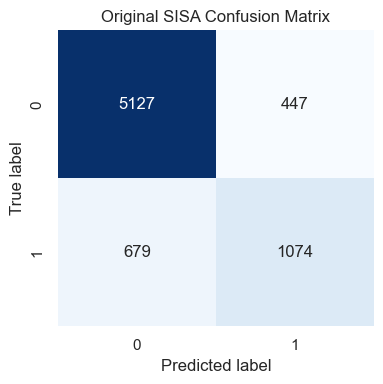

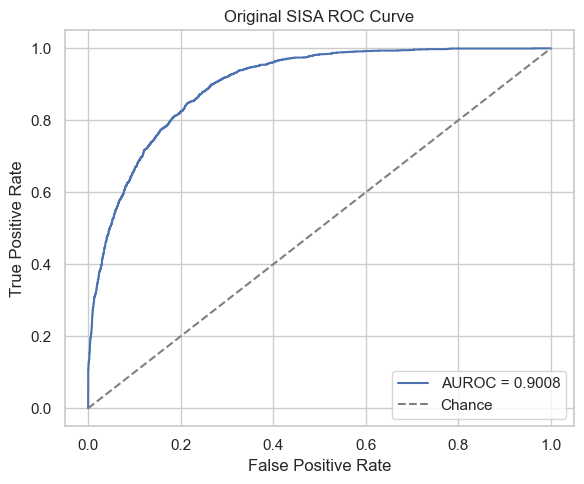

In [36]:
original_cm = confusion_matrix(y_test, original_sisa_test_predictions)
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(original_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Original SISA Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
fig.tight_layout()
fig.savefig(sisa_figures_dir / "original_sisa_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, original_sisa_test_probabilities)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUROC = {original_sisa_metrics['auroc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("Original SISA ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
fig.tight_layout()
fig.savefig(sisa_figures_dir / "original_sisa_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 7.2 Reference-Based Unlearning Evaluation

The existing shared evaluator is used for SISA. It separately reports predictive utility, forget-set fidelity to full retraining, and membership-inference diagnostic values. The complete forget set is used for every scenario.

### 7.2.1 Configure Membership-Inference Diagnostic Context

The current positive control is retained as invalid, so MIA results are interpreted as inconclusive rather than evidence of privacy.

In [37]:
positive_control_auc = 0.502634
positive_control_valid = False
sisa_evaluation_rows = []
sisa_forget_detail_frames = []

### 7.2.2 Run Shared Evaluation for S1-S5

Each scenario passes a callable SISA predictor into the shared evaluator, alongside the baseline and full-retraining reference model.

In [38]:
for scenario in scenario_names:
    scenario_efficiency = sisa_efficiency_summary.loc[sisa_efficiency_summary["scenario"] == scenario].iloc[0]
    evaluation_row, detail_tables = evaluate_unlearning_method(
        original_model=baseline_model,
        unlearned_model=sisa_predictors[scenario],
        retrained_model=retrained_models[scenario],
        X_retain=X_train_processed.loc[retain_indices[scenario]],
        y_retain=y_train.loc[retain_indices[scenario]],
        X_forget=X_train_processed.loc[forget_indices[scenario]],
        y_forget=y_train.loc[forget_indices[scenario]],
        X_test=X_test_processed,
        y_test=y_test,
        scenario_name=scenario,
        method_name="sisa",
        runtime=float(scenario_efficiency["total_deletion_runtime_seconds"]),
        optimizer_steps=int(scenario_efficiency["total_deletion_optimizer_steps"]),
        random_seed=RANDOM_SEED,
        mia_positive_control_auc=positive_control_auc,
        mia_positive_control_valid=positive_control_valid,
        return_details=True,
    )
    sisa_evaluation_rows.append(evaluation_row)
    sisa_forget_detail_frames.extend(
        [detail_tables["forget_unlearned"], detail_tables["forget_retrained"], detail_tables["forget_original"]]
    )

sisa_unlearning_evaluation = pd.concat(sisa_evaluation_rows, ignore_index=True)
sisa_forget_details = pd.concat(sisa_forget_detail_frames, ignore_index=True)

### 7.2.3 Build Evaluation Summary Tables

The result rows are split into predictive utility, forget-set fidelity and membership-inference diagnostic views.

In [39]:
sisa_utility_table = sisa_unlearning_evaluation[
    [
        "scenario", "method", "test_accuracy", "test_precision", "test_recall", "test_f1", "test_auroc",
        "test_loss", "retain_loss", "delta_accuracy", "delta_recall", "delta_f1", "delta_auroc",
        "delta_test_loss", "test_agreement_retrain", "test_probability_mad", "runtime_seconds", "optimizer_steps",
    ]
]
sisa_forget_set_fidelity_table = sisa_unlearning_evaluation[
    [
        "scenario", "method", "forget_size", "forget_percentage", "forget_ks_statistic", "forget_ks_pvalue",
        "forget_wasserstein", "forget_mean_loss_gap", "forget_probability_mad", "forget_agreement_retrain",
        "original_retrain_forget_ks", "original_retrain_forget_wasserstein",
    ]
]
sisa_mia_table = sisa_unlearning_evaluation[
    [
        "scenario", "method", "mia_auroc", "mia_attack_advantage", "mia_auc_ci_low", "mia_auc_ci_high",
        "mia_positive_control_auc", "mia_positive_control_valid", "mia_interpretation",
    ]
]

display(sisa_utility_table)
display(sisa_forget_set_fidelity_table)
sisa_mia_table

,scenario,method,test_accuracy,test_precision,test_recall,test_f1,test_auroc,test_loss,retain_loss,delta_accuracy,delta_recall,delta_f1,delta_auroc,delta_test_loss,test_agreement_retrain,test_probability_mad,runtime_seconds,optimizer_steps
0,s1_random_1_percent,sisa,0.846049,0.710438,0.601825,0.651637,0.900655,0.329239,0.325324,-0.011737,-0.019966,-0.024962,-0.009201,0.017157,0.944043,0.049169,11.361497,600
1,s2_random_5_percent,sisa,0.844275,0.708731,0.592698,0.645542,0.898890,0.332603,0.328900,-0.012147,-0.033086,-0.030367,-0.010469,0.019613,0.940358,0.053615,11.147639,596
2,s3_simulated_data_provider_withdrawal,sisa,0.843319,0.700730,0.602396,0.647853,0.899253,0.331593,0.327826,-0.012693,-0.002852,-0.020073,-0.010890,0.019763,0.941449,0.051025,10.866899,600
3,s4_random_10_percent,sisa,0.843183,0.705163,0.592128,0.643721,0.898209,0.333317,0.329662,-0.012283,-0.031945,-0.030132,-0.011229,0.020561,0.940494,0.055538,11.876665,500
4,s5_retention_expiry,sisa,0.840863,0.696848,0.592698,0.640567,0.896950,0.334961,0.311813,-0.015422,-0.010268,-0.026941,-0.011487,0.020675,0.938993,0.055153,12.857334,500


,scenario,method,forget_size,forget_percentage,forget_ks_statistic,forget_ks_pvalue,forget_wasserstein,forget_mean_loss_gap,forget_probability_mad,forget_agreement_retrain,original_retrain_forget_ks,original_retrain_forget_wasserstein
0,s1_random_1_percent,sisa,342,0.010003,0.187135,1.192880e-05,0.025683,0.002403,0.042175,0.967836,0.035088,0.015112
1,s2_random_5_percent,sisa,1709,0.049987,0.167934,1.887788e-21,0.027684,0.024884,0.053856,0.934465,0.015214,0.008622
2,s3_simulated_data_provider_withdrawal,sisa,1698,0.049665,0.170789,4.915149e-22,0.031468,0.013775,0.050244,0.945819,0.020612,0.013181
3,s4_random_10_percent,sisa,3419,0.100003,0.197426,1.128428e-58,0.036247,0.020466,0.053342,0.941211,0.011992,0.014658
4,s5_retention_expiry,sisa,5585,0.163357,0.133393,1.039407e-43,0.068285,0.025756,0.077812,0.907252,0.035452,0.038243


,scenario,method,mia_auroc,mia_attack_advantage,mia_auc_ci_low,mia_auc_ci_high,mia_positive_control_auc,mia_positive_control_valid,mia_interpretation
0,s1_random_1_percent,sisa,0.488992,0.022015,0.443269,0.526584,0.502634,False,inconclusive
1,s2_random_5_percent,sisa,0.503640,0.007280,0.486040,0.521195,0.502634,False,inconclusive
2,s3_simulated_data_provider_withdrawal,sisa,0.493159,0.013682,0.473756,0.512531,0.502634,False,inconclusive
3,s4_random_10_percent,sisa,0.496055,0.007891,0.482949,0.507610,0.502634,False,inconclusive
4,s5_retention_expiry,sisa,0.623511,0.247021,0.614661,0.633277,0.502634,False,inconclusive


# 8. Compare Results

SISA is an ensemble of isolated shard models, while the baseline and full-retraining references are single MLPs. These comparison diagnostics help separate architecture effects from deletion effects.

## 8.1 Define Probability-Loss Comparison Helper

This helper converts probability vectors into predictions and per-record losses for architectural comparison tables.

In [40]:
def prediction_loss_details(probabilities, labels):
    probabilities = validate_probability_vector(probabilities, len(labels), "comparison probabilities")
    eps = 1e-7
    log_probs = np.clip(probabilities, eps, 1 - eps)
    labels_array = labels.to_numpy()
    losses = -(labels_array * np.log(log_probs) + (1 - labels_array) * np.log(1 - log_probs))
    predictions = (probabilities >= CLASSIFICATION_THRESHOLD).astype(int)
    return predictions, losses

## 8.2 Compare SISA, Original SISA and Full Retraining

The comparison table reports prediction agreement, probability differences and loss differences on test and forget records.

In [41]:
architectural_rows = []
for scenario in scenario_names:
    retrain_test_probs, retrain_test_preds = predict_with_model(retrained_models[scenario], X_test_processed)
    unlearned_test_probs = sisa_predictors[scenario](X_test_processed)
    original_test_probs = original_sisa_predictor(X_test_processed)
    unlearned_test_preds, unlearned_test_losses = prediction_loss_details(unlearned_test_probs, y_test)
    original_test_preds, original_test_losses = prediction_loss_details(original_test_probs, y_test)
    _, retrain_test_losses = prediction_loss_details(retrain_test_probs, y_test)

    forget_X = X_train_processed.loc[forget_indices[scenario]]
    forget_y = y_train.loc[forget_indices[scenario]]
    retrain_forget_probs, retrain_forget_preds = predict_with_model(retrained_models[scenario], forget_X)
    unlearned_forget_probs = sisa_predictors[scenario](forget_X)
    original_forget_probs = original_sisa_predictor(forget_X)
    unlearned_forget_preds, unlearned_forget_losses = prediction_loss_details(unlearned_forget_probs, forget_y)
    original_forget_preds, original_forget_losses = prediction_loss_details(original_forget_probs, forget_y)
    _, retrain_forget_losses = prediction_loss_details(retrain_forget_probs, forget_y)

    for split_name, a_name, b_name, a_probs, b_probs, a_preds, b_preds, a_losses, b_losses in [
        ("test", "original_sisa", "full_retraining", original_test_probs, retrain_test_probs, original_test_preds, retrain_test_preds, original_test_losses, retrain_test_losses),
        ("test", "unlearned_sisa", "full_retraining", unlearned_test_probs, retrain_test_probs, unlearned_test_preds, retrain_test_preds, unlearned_test_losses, retrain_test_losses),
        ("test", "unlearned_sisa", "original_sisa", unlearned_test_probs, original_test_probs, unlearned_test_preds, original_test_preds, unlearned_test_losses, original_test_losses),
        ("forget", "original_sisa", "full_retraining", original_forget_probs, retrain_forget_probs, original_forget_preds, retrain_forget_preds, original_forget_losses, retrain_forget_losses),
        ("forget", "unlearned_sisa", "full_retraining", unlearned_forget_probs, retrain_forget_probs, unlearned_forget_preds, retrain_forget_preds, unlearned_forget_losses, retrain_forget_losses),
        ("forget", "unlearned_sisa", "original_sisa", unlearned_forget_probs, original_forget_probs, unlearned_forget_preds, original_forget_preds, unlearned_forget_losses, original_forget_losses),
    ]:
        architectural_rows.append(
            {
                "scenario": scenario,
                "split": split_name,
                "model_a": a_name,
                "model_b": b_name,
                "prediction_agreement": float(np.mean(a_preds == b_preds)),
                "probability_mad": float(np.mean(np.abs(a_probs - b_probs))),
                "mean_loss_difference": float(np.mean(a_losses - b_losses)),
            }
        )

sisa_architectural_comparison = pd.DataFrame(architectural_rows)
sisa_architectural_comparison.to_csv(sisa_tables_dir / "sisa_architectural_comparison.csv", index=False)
sisa_architectural_comparison.head(15)

,scenario,split,model_a,model_b,prediction_agreement,probability_mad,mean_loss_difference
0,s1_random_1_percent,test,original_sisa,full_retraining,0.944589,0.048291,0.016543
1,s1_random_1_percent,test,unlearned_sisa,full_retraining,0.944043,0.049169,0.017157
2,s1_random_1_percent,test,unlearned_sisa,original_sisa,0.995087,0.005029,0.000614
3,s1_random_1_percent,forget,original_sisa,full_retraining,0.967836,0.041466,0.001424
4,s1_random_1_percent,forget,unlearned_sisa,full_retraining,0.967836,0.042175,0.002403
5,s1_random_1_percent,forget,unlearned_sisa,original_sisa,0.994152,0.004634,0.000979
6,s2_random_5_percent,test,original_sisa,full_retraining,0.944861,0.048229,0.015635
7,s2_random_5_percent,test,unlearned_sisa,full_retraining,0.940358,0.053615,0.019613
8,s2_random_5_percent,test,unlearned_sisa,original_sisa,0.990310,0.010808,0.003978
9,s2_random_5_percent,forget,original_sisa,full_retraining,0.943827,0.048606,0.019882


# 9. Results Tables

The tables below summarize configuration, partitions, original setup, deletion work, predictive utility, forget-set fidelity and membership-inference diagnostics.

In [42]:
display(sisa_configuration_table)
display(shard_summary)
display(slice_summary)
display(original_sisa_training_summary)
display(original_sisa_utility)
display(forget_records_by_shard_and_slice.head(20))
display(sisa_deletion_work)
display(sisa_efficiency_summary)
display(sisa_utility_table)
display(sisa_forget_set_fidelity_table)
display(sisa_mia_table)
sisa_architectural_comparison.head(20)

,setting,value
0,method,sisa
1,number_of_shards,5
2,number_of_slices_per_shard,5
3,aggregation,mean_predicted_probability
4,classification_threshold,0.5
5,random_seed,42
6,model_architecture,AdultIncomeMLP_108_64_32_1_dropout_0.2
7,loss,BCEWithLogitsLoss
8,optimizer,Adam
9,batch_size,256


,shard_id,record_count,class_0_count,class_1_count,class_0_proportion,class_1_proportion
0,1,6838,5202,1636,0.760749,0.239251
1,2,6838,5202,1636,0.760749,0.239251
2,3,6838,5202,1636,0.760749,0.239251
3,4,6838,5201,1637,0.760603,0.239397
4,5,6837,5201,1636,0.760714,0.239286


,shard_id,slice_id,slice_record_count,class_0_count,class_1_count,cumulative_record_count,class_1_proportion
0,1,1,1368,1039,329,1368,0.240497
1,1,2,1368,1025,343,2736,0.250731
2,1,3,1368,1039,329,4104,0.240497
3,1,4,1367,1053,314,5471,0.229700
4,1,5,1367,1046,321,6838,0.234821
5,2,1,1368,1035,333,1368,0.243421
6,2,2,1368,1019,349,2736,0.255117
7,2,3,1368,1053,315,4104,0.230263
8,2,4,1367,1038,329,5471,0.240673
9,2,5,1367,1057,310,6838,0.226774


,shard_id,slice_id,slice_record_count,cumulative_record_count,epochs_completed,optimizer_steps,final_training_loss,final_validation_loss,runtime_seconds,starting_checkpoint,saved_checkpoint,seed
0,1,1,1368,1368,4,24,0.591801,0.570265,2.099520,deterministic_initial_state,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
1,1,2,1368,2736,4,24,0.457623,0.423464,0.381238,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
2,1,3,1368,4104,4,24,0.354769,0.338923,0.352694,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
3,1,4,1367,5471,4,24,0.342943,0.322796,0.450573,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
4,1,5,1367,6838,4,24,0.324253,0.316377,0.336918,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,43
5,2,1,1368,1368,4,24,0.645135,0.616373,0.386229,deterministic_initial_state,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
6,2,2,1368,2736,4,24,0.472152,0.437004,0.382959,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
7,2,3,1368,4104,4,24,0.361193,0.349694,0.348710,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
8,2,4,1367,5471,4,24,0.346608,0.328039,0.359269,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44
9,2,5,1367,6838,4,24,0.307144,0.323684,0.364537,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,/Users/niamhhughes/Desktop/Desktop - Niamh’s M...,44


,model,accuracy,precision,recall,f1,auroc,binary_cross_entropy_loss
0,original_sisa_ensemble,0.846322,0.706114,0.612664,0.656078,0.900787,0.328625


...

,scenario,forget_size,affected_shards,total_slices_retrained,total_retained_records_reprocessed,total_deletion_optimizer_steps,total_deletion_runtime_seconds,original_sisa_setup_runtime_seconds,full_retraining_runtime_seconds
0,s1_random_1_percent,342,5,25,33847,600,11.361497,11.104931,6.158163
1,s2_random_5_percent,1709,5,25,32480,596,11.147639,11.104931,6.309743
2,s3_simulated_data_provider_withdrawal,1698,5,25,32491,600,10.866899,11.104931,4.582676
3,s4_random_10_percent,3419,5,25,30770,500,11.876665,11.104931,5.082448
4,s5_retention_expiry,5585,5,25,28604,500,12.857334,11.104931,5.083569


,scenario,method,test_accuracy,test_precision,test_recall,test_f1,test_auroc,test_loss,retain_loss,delta_accuracy,delta_recall,delta_f1,delta_auroc,delta_test_loss,test_agreement_retrain,test_probability_mad,runtime_seconds,optimizer_steps
0,s1_random_1_percent,sisa,0.846049,0.710438,0.601825,0.651637,0.900655,0.329239,0.325324,-0.011737,-0.019966,-0.024962,-0.009201,0.017157,0.944043,0.049169,11.361497,600
1,s2_random_5_percent,sisa,0.844275,0.708731,0.592698,0.645542,0.898890,0.332603,0.328900,-0.012147,-0.033086,-0.030367,-0.010469,0.019613,0.940358,0.053615,11.147639,596
2,s3_simulated_data_provider_withdrawal,sisa,0.843319,0.700730,0.602396,0.647853,0.899253,0.331593,0.327826,-0.012693,-0.002852,-0.020073,-0.010890,0.019763,0.941449,0.051025,10.866899,600
3,s4_random_10_percent,sisa,0.843183,0.705163,0.592128,0.643721,0.898209,0.333317,0.329662,-0.012283,-0.031945,-0.030132,-0.011229,0.020561,0.940494,0.055538,11.876665,500
4,s5_retention_expiry,sisa,0.840863,0.696848,0.592698,0.640567,0.896950,0.334961,0.311813,-0.015422,-0.010268,-0.026941,-0.011487,0.020675,0.938993,0.055153,12.857334,500


,scenario,method,forget_size,forget_percentage,forget_ks_statistic,forget_ks_pvalue,forget_wasserstein,forget_mean_loss_gap,forget_probability_mad,forget_agreement_retrain,original_retrain_forget_ks,original_retrain_forget_wasserstein
0,s1_random_1_percent,sisa,342,0.010003,0.187135,1.192880e-05,0.025683,0.002403,0.042175,0.967836,0.035088,0.015112
1,s2_random_5_percent,sisa,1709,0.049987,0.167934,1.887788e-21,0.027684,0.024884,0.053856,0.934465,0.015214,0.008622
2,s3_simulated_data_provider_withdrawal,sisa,1698,0.049665,0.170789,4.915149e-22,0.031468,0.013775,0.050244,0.945819,0.020612,0.013181
3,s4_random_10_percent,sisa,3419,0.100003,0.197426,1.128428e-58,0.036247,0.020466,0.053342,0.941211,0.011992,0.014658
4,s5_retention_expiry,sisa,5585,0.163357,0.133393,1.039407e-43,0.068285,0.025756,0.077812,0.907252,0.035452,0.038243


,scenario,method,mia_auroc,mia_attack_advantage,mia_auc_ci_low,mia_auc_ci_high,mia_positive_control_auc,mia_positive_control_valid,mia_interpretation
0,s1_random_1_percent,sisa,0.488992,0.022015,0.443269,0.526584,0.502634,False,inconclusive
1,s2_random_5_percent,sisa,0.503640,0.007280,0.486040,0.521195,0.502634,False,inconclusive
2,s3_simulated_data_provider_withdrawal,sisa,0.493159,0.013682,0.473756,0.512531,0.502634,False,inconclusive
3,s4_random_10_percent,sisa,0.496055,0.007891,0.482949,0.507610,0.502634,False,inconclusive
4,s5_retention_expiry,sisa,0.623511,0.247021,0.614661,0.633277,0.502634,False,inconclusive


,scenario,split,model_a,model_b,prediction_agreement,probability_mad,mean_loss_difference
0,s1_random_1_percent,test,original_sisa,full_retraining,0.944589,0.048291,0.016543
1,s1_random_1_percent,test,unlearned_sisa,full_retraining,0.944043,0.049169,0.017157
2,s1_random_1_percent,test,unlearned_sisa,original_sisa,0.995087,0.005029,0.000614
3,s1_random_1_percent,forget,original_sisa,full_retraining,0.967836,0.041466,0.001424
4,s1_random_1_percent,forget,unlearned_sisa,full_retraining,0.967836,0.042175,0.002403
5,s1_random_1_percent,forget,unlearned_sisa,original_sisa,0.994152,0.004634,0.000979
6,s2_random_5_percent,test,original_sisa,full_retraining,0.944861,0.048229,0.015635
7,s2_random_5_percent,test,unlearned_sisa,full_retraining,0.940358,0.053615,0.019613
8,s2_random_5_percent,test,unlearned_sisa,original_sisa,0.990310,0.010808,0.003978
9,s2_random_5_percent,forget,original_sisa,full_retraining,0.943827,0.048606,0.019882


# 10. Interpretation

The interpretation is generated from computed result tables. It separates initial setup cost from deletion-request cost and treats membership-inference diagnostics as inconclusive because the available positive control is not valid.

In [43]:
best_utility = sisa_utility_table["test_accuracy"].max()
worst_utility = sisa_utility_table["test_accuracy"].min()
min_runtime = sisa_efficiency_summary["total_deletion_runtime_seconds"].min()
max_runtime = sisa_efficiency_summary["total_deletion_runtime_seconds"].max()
min_wasserstein = sisa_forget_set_fidelity_table["forget_wasserstein"].min()
max_wasserstein = sisa_forget_set_fidelity_table["forget_wasserstein"].max()
max_affected_shards = sisa_efficiency_summary["affected_shards"].max()
most_retrained = sisa_efficiency_summary.sort_values("total_slices_retrained", ascending=False).iloc[0]

interpretation_points = [
    f"Original SISA test accuracy was {original_sisa_metrics['accuracy']:.4f} with AUROC {original_sisa_metrics['auroc']:.4f}.",
    f"After deletion, SISA test accuracy ranged from {worst_utility:.4f} to {best_utility:.4f} across scenarios.",
    f"SISA deletion-request runtime ranged from {min_runtime:.2f} to {max_runtime:.2f} seconds; the original SISA setup runtime was {original_sisa_setup_runtime_seconds:.2f} seconds and is not counted as request runtime.",
    f"Forget-set Wasserstein distance to the full-retraining reference ranged from {min_wasserstein:.4f} to {max_wasserstein:.4f}; lower values indicate stronger forget-set fidelity.",
    f"The maximum affected shard count was {max_affected_shards} out of {NUM_SHARDS}.",
    f"The scenario with the most retrained slices was {most_retrained['scenario']} with {int(most_retrained['total_slices_retrained'])} slices retrained.",
    "Membership-inference diagnostics are labelled inconclusive because the loss-based positive control AUROC is approximately 0.5026 and not valid.",
    "SISA's main strength is efficient isolated retraining after setup; its main limitation is that the ensemble architecture differs from the single-MLP full-retraining reference.",
]
for point in interpretation_points:
    print(f"- {point}")

- Original SISA test accuracy was 0.8463 with AUROC 0.9008.
- After deletion, SISA test accuracy ranged from 0.8409 to 0.8460 across scenarios.
- SISA deletion-request runtime ranged from 10.87 to 12.86 seconds; the original SISA setup runtime was 11.10 seconds and is not counted as request runtime.
- Forget-set Wasserstein distance to the full-retraining reference ranged from 0.0257 to 0.0683; lower values indicate stronger forget-set fidelity.
- The maximum affected shard count was 5 out of 5.
- The scenario with the most retrained slices was s1_random_1_percent with 25 slices retrained.
- Membership-inference diagnostics are labelled inconclusive because the loss-based positive control AUROC is approximately 0.5026 and not valid.
- SISA's main strength is efficient isolated retraining after setup; its main limitation is that the ensemble architecture differs from the single-MLP full-retraining reference.


# 11. Save Outputs

This section saves the shared SISA evaluation rows, figures, tables, prediction files and summary outputs under `results/sisa/adult/`.

## 11.1 Save Shared Evaluation Rows

Only the five genuine SISA unlearning rows are written to the method-specific and shared evaluation CSV files. Original setup rows, shard rows and dummy/interface-test rows are excluded.

In [44]:
sisa_evaluation_path = sisa_metrics_dir / "unlearning_evaluation.csv"
sisa_forget_details_path = sisa_tables_dir / "forget_record_evaluation.csv"
sisa_unlearning_evaluation.to_csv(sisa_evaluation_path, index=False)
sisa_forget_details.to_csv(sisa_forget_details_path, index=False)

current_evaluation_path = project_root / "results" / "unlearning_evaluation_current.csv"
if current_evaluation_path.exists():
    current_unlearning_evaluation = pd.read_csv(current_evaluation_path)
    current_unlearning_evaluation = current_unlearning_evaluation.loc[current_unlearning_evaluation["method"] != "sisa"]
    current_unlearning_evaluation = pd.concat([current_unlearning_evaluation, sisa_unlearning_evaluation], ignore_index=True)
else:
    current_unlearning_evaluation = sisa_unlearning_evaluation.copy()
current_unlearning_evaluation.to_csv(current_evaluation_path, index=False)

assert (current_unlearning_evaluation["method"] == "sisa").sum() == 5
assert not (current_unlearning_evaluation["scenario"] == "callable_interface_test").any()
print(f"Saved SISA evaluation to: {sisa_evaluation_path}")
print(f"Updated shared evaluation table: {current_evaluation_path}")
current_unlearning_evaluation.loc[current_unlearning_evaluation["method"] == "sisa"]

Saved SISA evaluation to: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/results/sisa/adult/metrics/unlearning_evaluation.csv
Updated shared evaluation table: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/results/unlearning_evaluation_current.csv


,scenario,forget_size,forget_percentage,method,seed,test_accuracy,test_precision,test_recall,test_f1,test_auroc,...,mia_auc_bootstrap_std,runtime_seconds,optimizer_steps,selected_learning_rate,selected_retain_weight,selection_eval_sample_size,selection_best_score,mia_positive_control_auc,mia_positive_control_valid,mia_interpretation
10,s1_random_1_percent,342,0.010003,sisa,42,0.846049,0.710438,0.601825,0.651637,0.900655,...,0.021923,11.361497,600,NaN,NaN,NaN,NaN,0.502634,False,inconclusive
11,s2_random_5_percent,1709,0.049987,sisa,42,0.844275,0.708731,0.592698,0.645542,0.898890,...,0.009384,11.147639,596,NaN,NaN,NaN,NaN,0.502634,False,inconclusive
12,s3_simulated_data_provider_withdrawal,1698,0.049665,sisa,42,0.843319,0.700730,0.602396,0.647853,0.899253,...,0.010461,10.866899,600,NaN,NaN,NaN,NaN,0.502634,False,inconclusive
13,s4_random_10_percent,3419,0.100003,sisa,42,0.843183,0.705163,0.592128,0.643721,0.898209,...,0.006973,11.876665,500,NaN,NaN,NaN,NaN,0.502634,False,inconclusive
14,s5_retention_expiry,5585,0.163357,sisa,42,0.840863,0.696848,0.592698,0.640567,0.896950,...,0.004996,12.857334,500,NaN,NaN,NaN,NaN,0.502634,False,inconclusive


## 11.2 Save Figures

These figures describe SISA partitions, deletion efficiency, predictive utility and forget-set fidelity. Lower distance values indicate stronger fidelity to the full-retraining reference.

### 11.2.1 Save Partition Figures

These plots describe shard balance and slice sizes in the fixed SISA partition.

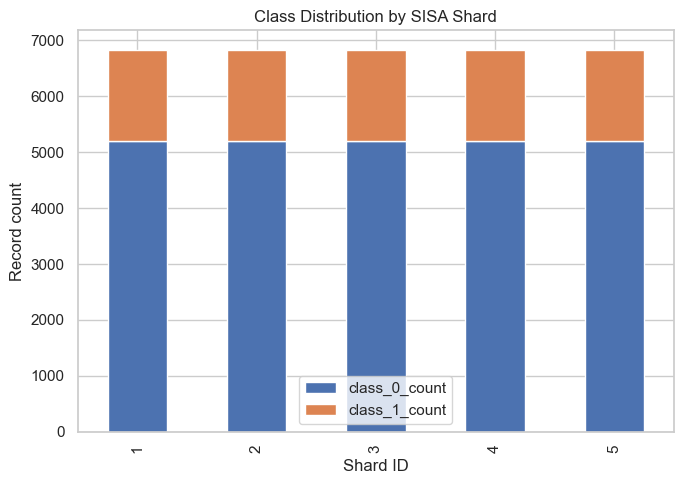

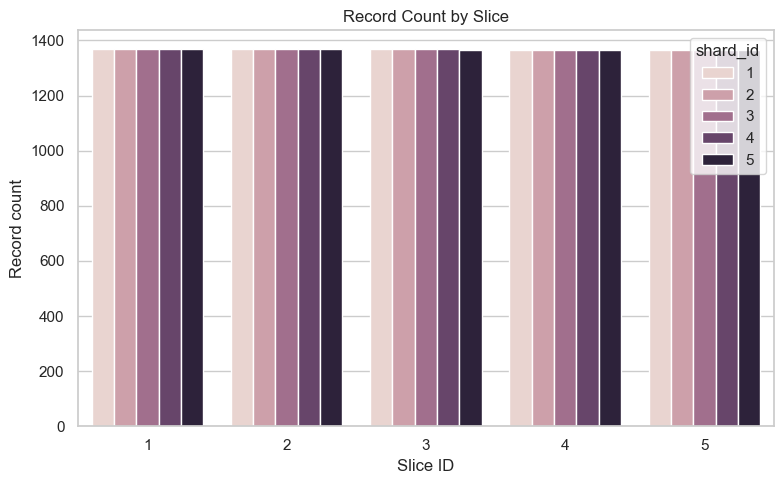

In [45]:
# Partition figures
fig, ax = plt.subplots(figsize=(7, 5))
shard_summary.set_index("shard_id")[["class_0_count", "class_1_count"]].plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Class Distribution by SISA Shard")
ax.set_xlabel("Shard ID")
ax.set_ylabel("Record count")
fig.tight_layout()
fig.savefig(sisa_figures_dir / "class_distribution_by_shard.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=slice_summary, x="slice_id", y="slice_record_count", hue="shard_id", ax=ax)
ax.set_title("Record Count by Slice")
ax.set_xlabel("Slice ID")
ax.set_ylabel("Record count")
fig.tight_layout()
fig.savefig(sisa_figures_dir / "record_count_by_slice.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.2.2 Save Forget-Request Mapping Figures

These plots show how deletion requests distribute across shards and slices.

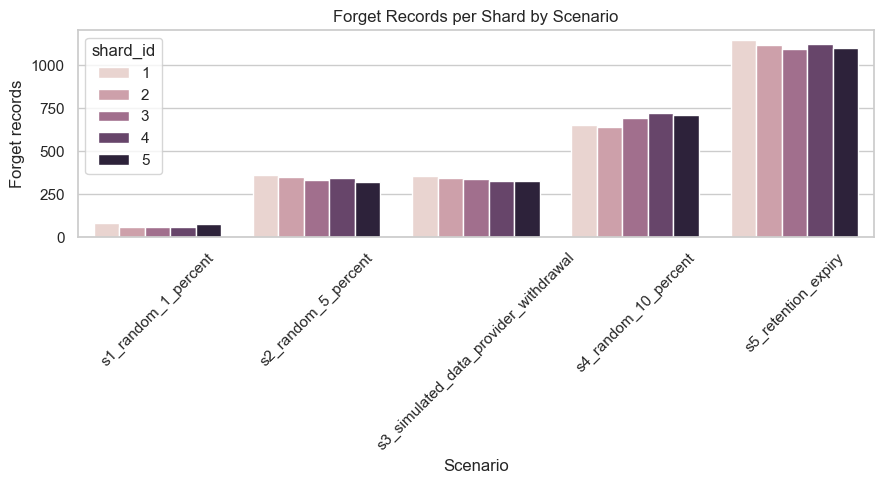

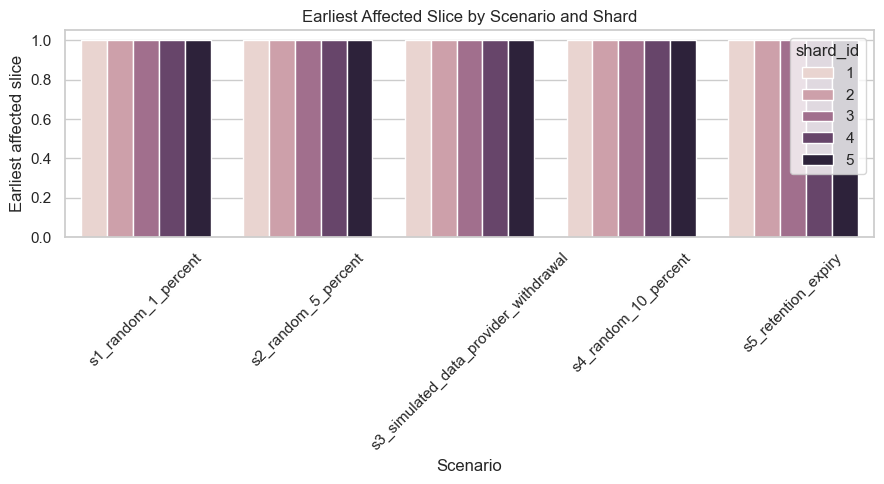

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=forget_records_per_shard, x="scenario", y="forget_count", hue="shard_id", ax=ax)
ax.set_title("Forget Records per Shard by Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Forget records")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(sisa_figures_dir / "forget_records_per_shard_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=earliest_affected_slice_table, x="scenario", y="earliest_affected_slice", hue="shard_id", ax=ax)
ax.set_title("Earliest Affected Slice by Scenario and Shard")
ax.set_xlabel("Scenario")
ax.set_ylabel("Earliest affected slice")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(sisa_figures_dir / "earliest_affected_slice_by_scenario_and_shard.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.2.3 Save Slice-Replay Work Figure

This plot summarises how much slice replay each scenario required.

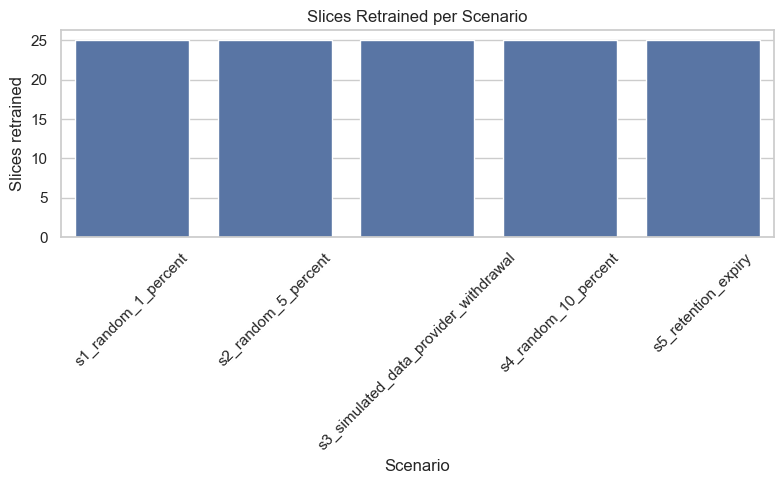

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=sisa_efficiency_summary, x="scenario", y="total_slices_retrained", ax=ax)
ax.set_title("Slices Retrained per Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Slices retrained")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(sisa_figures_dir / "slices_retrained_per_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.2.4 Save Runtime Figures

These plots compare request deletion runtime with full-retraining runtime.

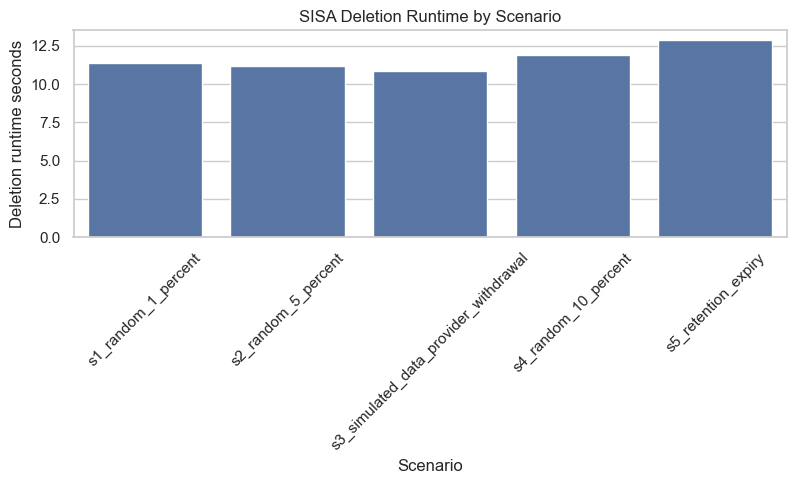

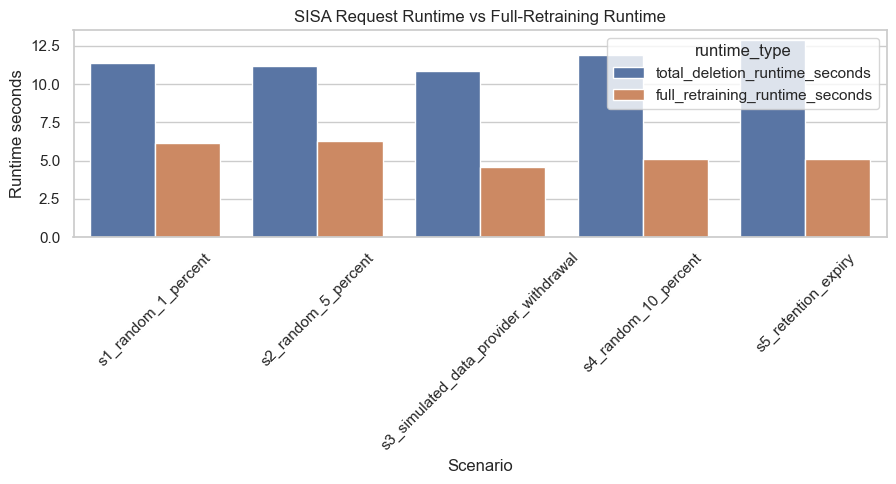

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=sisa_efficiency_summary, x="scenario", y="total_deletion_runtime_seconds", ax=ax)
ax.set_title("SISA Deletion Runtime by Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Deletion runtime seconds")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(sisa_figures_dir / "sisa_deletion_runtime_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

runtime_compare = sisa_efficiency_summary.melt(
    id_vars="scenario",
    value_vars=["total_deletion_runtime_seconds", "full_retraining_runtime_seconds"],
    var_name="runtime_type",
    value_name="runtime_seconds",
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=runtime_compare, x="scenario", y="runtime_seconds", hue="runtime_type", ax=ax)
ax.set_title("SISA Request Runtime vs Full-Retraining Runtime")
ax.set_xlabel("Scenario")
ax.set_ylabel("Runtime seconds")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(sisa_figures_dir / "sisa_runtime_vs_full_retraining_runtime.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.2.5 Save Shared-Evaluation Figures

These plots show utility deltas and forget-set fidelity distances from the shared evaluator.

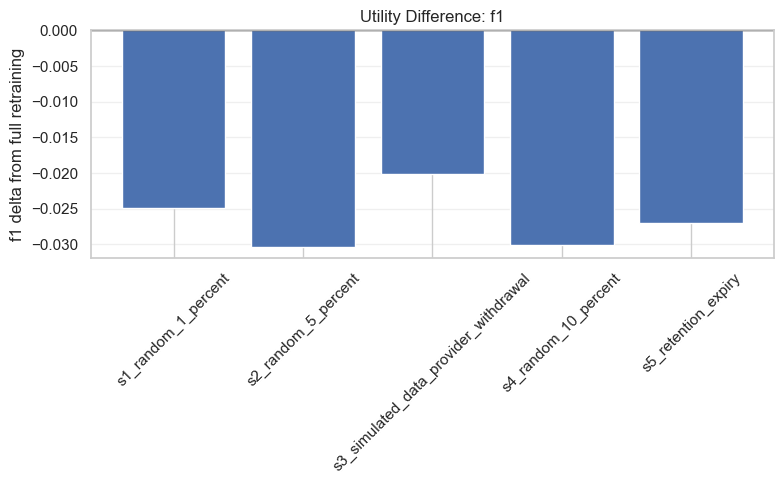

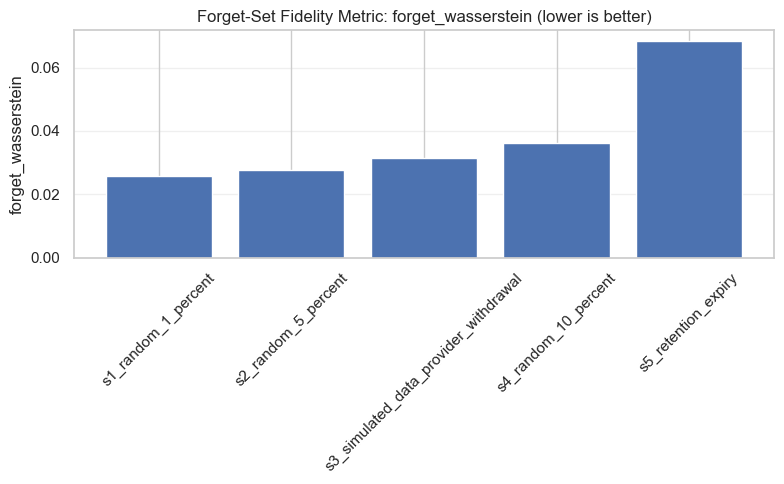

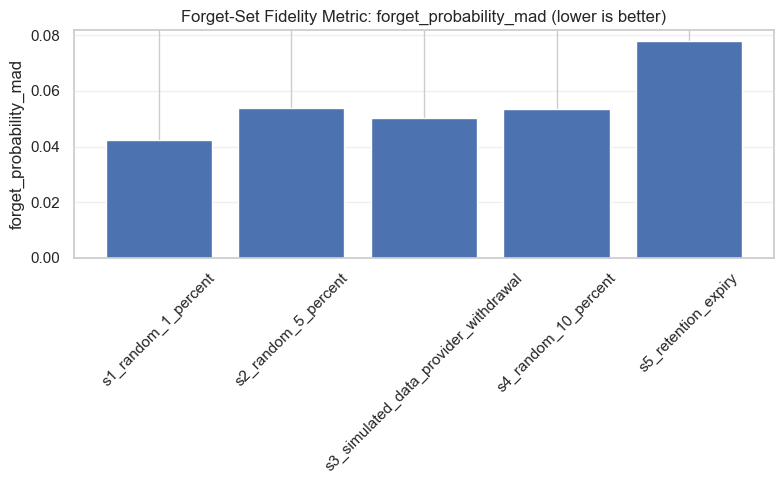

In [49]:
fig, _ = plot_utility_delta(sisa_unlearning_evaluation, metric="f1")
fig.savefig(sisa_figures_dir / "utility_delta_f1_from_full_retraining.png", dpi=300, bbox_inches="tight")
plt.show()

fig, _ = plot_forget_set_fidelity(sisa_unlearning_evaluation, metric="forget_wasserstein")
fig.savefig(sisa_figures_dir / "forget_wasserstein_across_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()

fig, _ = plot_forget_set_fidelity(sisa_unlearning_evaluation, metric="forget_probability_mad")
fig.savefig(sisa_figures_dir / "forget_probability_mad_across_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.2.6 Save Representative Forget-Loss ECDF

The S1 ECDF provides one detailed view of SISA forget-loss behaviour against full retraining.

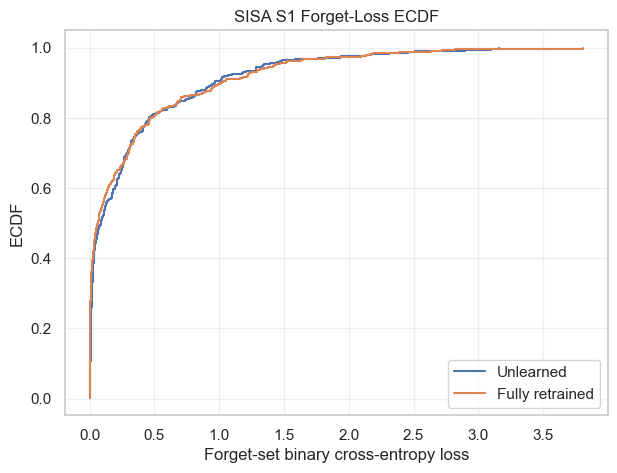

In [50]:
representative_scenario = "s1_random_1_percent"
representative_unlearned = sisa_forget_details[
    (sisa_forget_details["scenario"] == representative_scenario)
    & (sisa_forget_details["model"] == "sisa")
]
representative_retrained = sisa_forget_details[
    (sisa_forget_details["scenario"] == representative_scenario)
    & (sisa_forget_details["model"] == "fully_retrained")
]
fig, _ = plot_forget_loss_ecdf(
    forget_unlearned=representative_unlearned,
    forget_retrained=representative_retrained,
    title="SISA S1 Forget-Loss ECDF",
)
fig.savefig(sisa_figures_dir / "representative_s1_forget_loss_ecdf.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.2.7 Save Deletion-Efficiency Diagnostics

These plots relate affected shards and deletion-driven probability change to scenario behaviour.

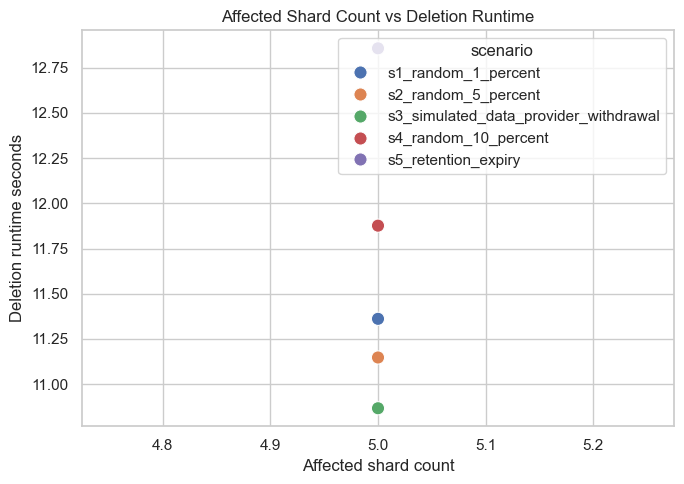

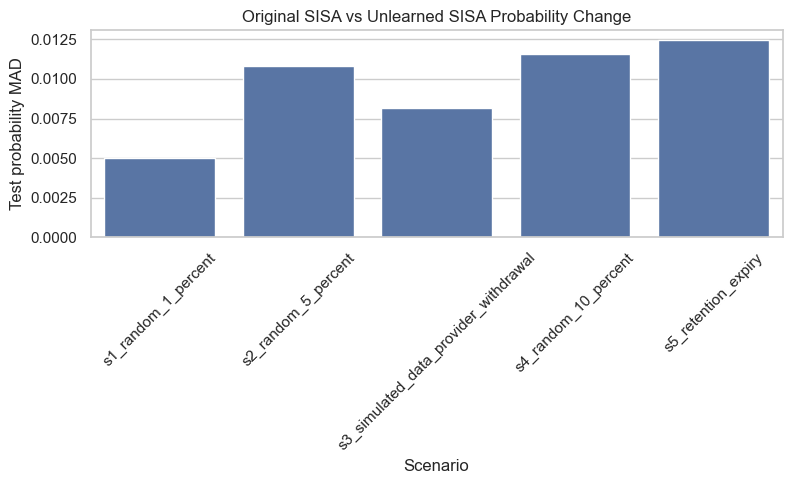

In [51]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=sisa_efficiency_summary, x="affected_shards", y="total_deletion_runtime_seconds", hue="scenario", s=90, ax=ax)
ax.set_title("Affected Shard Count vs Deletion Runtime")
ax.set_xlabel("Affected shard count")
ax.set_ylabel("Deletion runtime seconds")
fig.tight_layout()
fig.savefig(sisa_figures_dir / "affected_shard_count_vs_deletion_runtime.png", dpi=300, bbox_inches="tight")
plt.show()

orig_change = sisa_architectural_comparison[
    (sisa_architectural_comparison["split"] == "test")
    & (sisa_architectural_comparison["model_a"] == "unlearned_sisa")
    & (sisa_architectural_comparison["model_b"] == "original_sisa")
]
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=orig_change, x="scenario", y="probability_mad", ax=ax)
ax.set_title("Original SISA vs Unlearned SISA Probability Change")
ax.set_xlabel("Scenario")
ax.set_ylabel("Test probability MAD")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(sisa_figures_dir / "original_vs_unlearned_sisa_probability_change.png", dpi=300, bbox_inches="tight")
plt.show()

## 11.3 Save Tables and Predictions

This section saves the remaining SISA tables and prediction files under `results/sisa/adult/`.

### 11.3.1 Save Summary Tables

The key evaluation, partition and mapping tables are written before prediction exports are generated.

In [52]:
sisa_utility_table.to_csv(sisa_metrics_dir / "sisa_utility_table.csv", index=False)
sisa_forget_set_fidelity_table.to_csv(sisa_metrics_dir / "sisa_forget_set_fidelity_table.csv", index=False)
sisa_mia_table.to_csv(sisa_metrics_dir / "sisa_mia_table.csv", index=False)
shard_summary.to_csv(sisa_tables_dir / "shard_summary.csv", index=False)
slice_summary.to_csv(sisa_tables_dir / "slice_summary.csv", index=False)
forget_records_per_shard.to_csv(sisa_tables_dir / "forget_records_per_shard.csv", index=False)
forget_records_per_slice.to_csv(sisa_tables_dir / "forget_records_per_slice.csv", index=False)
earliest_affected_slice_table.to_csv(sisa_tables_dir / "earliest_affected_slice.csv", index=False)

### 11.3.2 Generate Scenario Prediction Tables

Scenario-specific test and forget predictions are generated from the callable SISA predictors.

In [53]:
scenario_prediction_frames = []
forget_prediction_frames = []
for scenario in scenario_names:
    test_probs = sisa_predictors[scenario](X_test_processed)
    test_preds = (test_probs >= CLASSIFICATION_THRESHOLD).astype(int)
    scenario_prediction_frames.append(
        pd.DataFrame(
            {
                "scenario": scenario,
                "original_index": X_test_processed.index,
                "y_true": y_test.to_numpy(),
                "y_prob": test_probs,
                "y_pred": test_preds,
            }
        )
    )
    forget_X = X_train_processed.loc[forget_indices[scenario]]
    forget_y = y_train.loc[forget_indices[scenario]]
    forget_probs = sisa_predictors[scenario](forget_X)
    forget_preds = (forget_probs >= CLASSIFICATION_THRESHOLD).astype(int)
    forget_prediction_frames.append(
        pd.DataFrame(
            {
                "scenario": scenario,
                "original_index": forget_X.index,
                "y_true": forget_y.to_numpy(),
                "y_prob": forget_probs,
                "y_pred": forget_preds,
            }
        )
    )

sisa_test_predictions = pd.concat(scenario_prediction_frames, ignore_index=True)
sisa_forget_predictions = pd.concat(forget_prediction_frames, ignore_index=True)

### 11.3.3 Save Prediction Tables

The exported prediction tables support later inspection without rerunning the notebook.

In [54]:
sisa_test_predictions.to_csv(sisa_predictions_dir / "sisa_test_predictions.csv", index=False)
sisa_forget_predictions.to_csv(sisa_predictions_dir / "sisa_forget_predictions.csv", index=False)

print(f"Saved SISA outputs under: {sisa_dir}")

Saved SISA outputs under: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/results/sisa/adult


# 12. Summary

This notebook implemented SISA unlearning with five shards and five slices per shard. It trained the original isolated shard models, handled S1-S5 deletion requests independently, reused unaffected shards, and evaluated the resulting systems against the full-retraining reference.

The summary below is computed from the saved result tables.

In [55]:
summary = {
    "number_of_shards": NUM_SHARDS,
    "number_of_slices_per_shard": NUM_SLICES,
    "original_sisa_setup_runtime_seconds": original_sisa_setup_runtime_seconds,
    "original_sisa_test_accuracy": original_sisa_metrics["accuracy"],
    "original_sisa_test_auroc": original_sisa_metrics["auroc"],
    "deletion_runtime_min_seconds": sisa_efficiency_summary["total_deletion_runtime_seconds"].min(),
    "deletion_runtime_max_seconds": sisa_efficiency_summary["total_deletion_runtime_seconds"].max(),
    "affected_shards_min": sisa_efficiency_summary["affected_shards"].min(),
    "affected_shards_max": sisa_efficiency_summary["affected_shards"].max(),
    "test_accuracy_min": sisa_utility_table["test_accuracy"].min(),
    "test_accuracy_max": sisa_utility_table["test_accuracy"].max(),
    "forget_wasserstein_min": sisa_forget_set_fidelity_table["forget_wasserstein"].min(),
    "forget_wasserstein_max": sisa_forget_set_fidelity_table["forget_wasserstein"].max(),
    "mia_status": "inconclusive",
    "main_limitation": "SISA is an ensemble of shard models, while the baseline and full-retraining reference are single MLPs.",
}
summary_table = pd.DataFrame([summary])
summary_table.to_csv(sisa_tables_dir / "sisa_summary.csv", index=False)
summary_table

,number_of_shards,number_of_slices_per_shard,original_sisa_setup_runtime_seconds,original_sisa_test_accuracy,original_sisa_test_auroc,deletion_runtime_min_seconds,deletion_runtime_max_seconds,affected_shards_min,affected_shards_max,test_accuracy_min,test_accuracy_max,forget_wasserstein_min,forget_wasserstein_max,mia_status,main_limitation
0,5,5,11.104931,0.846322,0.900787,10.866899,12.857334,5,5,0.840863,0.846049,0.025683,0.068285,inconclusive,"SISA is an ensemble of shard models, while the..."


## 12.1 Final Validation

The final checks confirm that every scenario was evaluated, the fixed partition was used throughout, no dummy rows were saved, complete forget sets were used, and exactly five SISA rows were appended to the shared evaluation table.

In [56]:
assert len(sisa_unlearning_evaluation) == 5
assert set(sisa_unlearning_evaluation["scenario"]) == set(scenario_names)
assert (sisa_unlearning_evaluation["method"] == "sisa").all()
assert shard_assignments["original_index"].is_unique
assert slice_assignments["original_index"].is_unique
assert set(shard_assignments["original_index"]) == set(training_index)
assert set(slice_assignments["original_index"]) == set(training_index)
assert (current_unlearning_evaluation["method"] == "sisa").sum() == 5
assert not (current_unlearning_evaluation["scenario"] == "callable_interface_test").any()
for scenario in scenario_names:
    assert int(sisa_unlearning_evaluation.loc[sisa_unlearning_evaluation["scenario"] == scenario, "forget_size"].iloc[0]) == len(forget_indices[scenario])
    scenario_work = sisa_deletion_work.loc[sisa_deletion_work["scenario"] == scenario]
    assert len(scenario_work) == NUM_SHARDS
    assert scenario_work.loc[scenario_work["shard_status"] == "unaffected", "deletion_optimizer_steps"].eq(0).all()
    assert scenario_work.loc[scenario_work["shard_status"] == "unaffected", "original_checkpoint_reused"].all()

print("SISA notebook validation passed.")

SISA notebook validation passed.
